# Contribution 3: Kernel Geometry — Multi-Run (5 Trains × 1 Fixed Test)

**Câu hỏi nghiên cứu:** Cấu trúc hình học của quantum kernel có thực sự tốt hơn classical kernel trên dữ liệu IDS không?

**Phương pháp multi-run:** Train trên 5 tập train khác nhau (`train_run1.csv` → `train_run5.csv`), test trên cùng 1 tập test cố định → báo cáo **mean ± std** để đánh giá độ ổn định.

**Pipeline:** `Cleaned.csv` → `selector.joblib` → `pca.joblib` → `scaler.joblib` → QSVM / SVM

**Các kernel được so sánh:** QSVM (ZZFeatureMap) · QSVM (ZFeatureMap, ablation) · SVM-Linear · SVM-Polynomial · SVM-RBF

**Các figures:**
1. **Figure 1**: Overview — Kernel heatmap + KTA bar + SV distribution + Decision boundary + Spearman delta + Margin distribution (representative run)
2. **Figure 2**: Decision Boundary — 5 kernels × 2 PC pairs (representative run)
3. **Figure 3**: Gram Matrices — 5 kernels (representative run)
4. **Figure 4 (NEW)**: F1-macro & Accuracy — mean ± std bar chart (all runs)
5. **Figure 5 (NEW)**: KTA — mean ± std bar chart (all runs)
6. **Figure 6 (NEW)**: n_SV — mean ± std bar chart (all runs)
7. **Figure 7 (NEW)**: Per-run F1 trend lines (all models across 5 runs)


## 1. Config & Imports

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os, time, json, warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, linear_kernel

from qiskit.circuit.library import zz_feature_map, z_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC

import qiskit, qiskit_machine_learning
print(f'Qiskit              : {qiskit.__version__}')
print(f'Qiskit ML           : {qiskit_machine_learning.__version__}')
print('Backend             : FidelityStatevectorKernel (statevector, noiseless, parallel)')

# ── Cấu hình chính ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
RUN_IDS      = [1, 2, 3, 4, 5]

N_QUBITS     = 4
ANGLE_MAX    = np.pi

REPS         = 2
ENTANGLEMENT = 'full'
C_QSVM       = 1.0
SHOTS        = 'sv'

REPS_Z       = 2
C_QSVM_Z     = 1.0

SVM_MODEL_KEYS = ['linear_mm', 'linear_std', 'poly_mm', 'poly_std', 'rbf_mm', 'rbf_std']
SVM_C_VALUES   = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 10.0], dtype=float)
SVM_C_BY_MODEL = dict(zip(SVM_MODEL_KEYS, SVM_C_VALUES))
POLY_DEGREE    = 2
RBF_GAMMA      = 'scale'

TRAIN_SIZE     = 1000
TEST_SIZE      = 300
KM_SAMPLE_SIZE = 100

LABEL_COLS = ['label', 'label_binary', 'label_multiclass', 'attack_category']

DATA_DIR   = '../data/processed_data'
MODELS_DIR = '../models'
OUTPUT_DIR = '../results/c3_multirun'
os.makedirs(OUTPUT_DIR, exist_ok=True)

QSVM_MODEL_DIR = f'{MODELS_DIR}/qsvm_cache'
os.makedirs(QSVM_MODEL_DIR, exist_ok=True)

MULTIRUN_CACHE_DIR = f'{QSVM_MODEL_DIR}/multirun_c3'
os.makedirs(MULTIRUN_CACHE_DIR, exist_ok=True)

def _fmt_c_for_tag(c):
    return f'{float(c):g}'.replace('.', 'p')

SVM_C_TAG  = '-'.join(
    f'{k.replace("_","")}{_fmt_c_for_tag(SVM_C_BY_MODEL[k])}' for k in SVM_MODEL_KEYS
)
CONFIG_TAG = (
    f'r{REPS}_{ENTANGLEMENT}'
    f'_cq{C_QSVM}'
    f'_cs{SVM_C_TAG}'
    f'_s{SHOTS}'
    f'_n{TRAIN_SIZE}'
    f'_t{TEST_SIZE}'
    f'_km{KM_SAMPLE_SIZE}'
)
CONFIG_TAG_Z = (
    f'z_r{REPS_Z}'
    f'_cq{C_QSVM_Z}'
    f'_cs{SVM_C_TAG}'
    f'_s{SHOTS}'
    f'_n{TRAIN_SIZE}'
    f'_t{TEST_SIZE}'
    f'_km{KM_SAMPLE_SIZE}'
)
TEST_PATH = f'{DATA_DIR}/NSL_KDD_Test_Sample{TEST_SIZE}.csv'

COLORS = {
    'quantum'  : '#1565C0',
    'quantum_z': '#F57C00',
    'linear'   : '#E53935',
    'poly'     : '#43A047',
    'rbf'      : '#8E24AA',
}
LABEL_NAMES = {
    'quantum'  : 'QSVM (ZZFeatureMap)',
    'quantum_z': 'QSVM (ZFeatureMap, no entangle)',
    'linear'   : 'SVM-Linear',
    'poly'     : f'SVM-Poly (deg=2)',
    'rbf'      : 'SVM-RBF',
}
np.random.seed(RANDOM_STATE)
print(f'CONFIG_TAG   : {CONFIG_TAG}')
print(f'CONFIG_TAG_Z : {CONFIG_TAG_Z}')
print(f'MULTIRUN_CACHE_DIR: {MULTIRUN_CACHE_DIR}')


Qiskit              : 2.3.0
Qiskit ML           : 0.9.0
Backend             : FidelityStatevectorKernel (statevector, noiseless, parallel)
CONFIG_TAG   : r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100
CONFIG_TAG_Z : z_r2_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100
MULTIRUN_CACHE_DIR: ../models/qsvm_cache/multirun_c3


## 2. Load Transformers & Pipeline Helpers

In [109]:
selector = joblib.load(f'{MODELS_DIR}/feature_selector_k20.joblib')
pca      = joblib.load(f'{MODELS_DIR}/pca_4components.joblib')
scaler   = joblib.load(f'{MODELS_DIR}/scaler_minmax_pi.joblib')

print(f'SelectKBest : k={selector.k}')
print(f'PCA         : n_components={pca.n_components_}, variance={pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'Scaler      : range=[{scaler.feature_range[0]:.4f}, {scaler.feature_range[1]:.4f}]')

PC_LABELS = [f'PC{i+1}' for i in range(N_QUBITS)]

def transform_pipeline(df, feature_cols):
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    X_pca = pca.transform(X_sel)
    return np.clip(scaler.transform(X_pca), 0, ANGLE_MAX)

def pca_only(df, feature_cols):
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    return pca.transform(X_sel)

def build_quantum_kernel():
    fm = zz_feature_map(feature_dimension=N_QUBITS, reps=REPS, entanglement=ENTANGLEMENT)
    return FidelityStatevectorKernel(feature_map=fm, shots=None, enforce_psd=True, cache_size=None)

def build_z_quantum_kernel():
    fm = z_feature_map(feature_dimension=N_QUBITS, reps=REPS_Z)
    return FidelityStatevectorKernel(feature_map=fm, shots=None, enforce_psd=True, cache_size=None)

def kernel_target_alignment(K, y):
    yy = y.astype(float).copy(); yy[yy == 0] = -1.0
    Y = np.outer(yy, yy)
    num = np.sum(K * Y)
    den = np.linalg.norm(K, 'fro') * np.linalg.norm(Y, 'fro')
    return float(num / den) if den > 1e-12 else 0.0

def compute_gram(X, label):
    if label == 'quantum':
        return build_quantum_kernel().evaluate(X)
    elif label == 'quantum_z':
        return build_z_quantum_kernel().evaluate(X)
    elif label == 'linear':
        return linear_kernel(X)
    elif label == 'poly':
        return polynomial_kernel(X, degree=POLY_DEGREE, gamma=1.0/X.shape[1], coef0=0)
    elif label == 'rbf':
        gv = 1.0/(X.shape[1]*X.var()) if RBF_GAMMA == 'scale' else float(RBF_GAMMA)
        return rbf_kernel(X, gamma=gv)
    raise ValueError(label)

def boundary_grid_fast(X, model, pc_pair=(0,1), n_grid=30, batch_size=50):
    medians = np.median(X, axis=0)
    i, j = pc_pair
    xx, yy = np.meshgrid(
        np.linspace(X[:,i].min()-0.05, X[:,i].max()+0.05, n_grid),
        np.linspace(X[:,j].min()-0.05, X[:,j].max()+0.05, n_grid)
    )
    pts = np.tile(medians, (xx.ravel().shape[0], 1))
    pts[:,i] = xx.ravel(); pts[:,j] = yy.ravel()
    Z_flat = []
    for start in range(0, len(pts), batch_size):
        batch = pts[start:start+batch_size]
        try:
            preds = np.sign(model.decision_function(batch)).astype(int)
        except AttributeError:
            preds = model.predict(batch)
        Z_flat.extend(preds)
    return xx, yy, np.array(Z_flat).reshape(xx.shape)

print('Helpers ready.')


SelectKBest : k=20
PCA         : n_components=4, variance=86.62%
Scaler      : range=[0.0000, 3.1416]
Helpers ready.


## 3. Single-Run Function (C3 Logic Preserved)

In [110]:
def run_c3_single(run_id, test_path):
    """
    Train trên train_run{run_id}.csv, test trên test_path cố định.
    Trả về dict chứa tất cả metrics + artifacts để vẽ figure.
    """
    print(f'\n[C3][run_{run_id}] ====== START ======')
    run_cache = f'{MULTIRUN_CACHE_DIR}/run_{run_id}'
    os.makedirs(run_cache, exist_ok=True)

    # ── Load data ──────────────────────────────────────────────────────────
    train_path = f'{DATA_DIR}/multi_run/train_run{run_id}.csv'
    if not os.path.exists(train_path):
        raise FileNotFoundError(f'[MISSING] {train_path}')

    df_train = pd.read_csv(train_path)
    df_test  = pd.read_csv(test_path)
    feature_cols = [c for c in df_train.columns if c not in LABEL_COLS]

    X_train      = transform_pipeline(df_train, feature_cols)
    y_train      = df_train['label_binary'].to_numpy(dtype=np.int64)
    X_test       = transform_pipeline(df_test,  feature_cols)
    y_test       = df_test['label_binary'].to_numpy(dtype=np.int64)
    X_train_pca  = pca_only(df_train, feature_cols)
    X_test_pca   = pca_only(df_test,  feature_cols)

    std_sc       = StandardScaler()
    X_train_std  = std_sc.fit_transform(X_train_pca)
    X_test_std   = std_sc.transform(X_test_pca)

    print(f'  Train: {X_train.shape} | class dist={np.bincount(y_train)}')
    print(f'  Test : {X_test.shape}  | class dist={np.bincount(y_test)}')

    # ── Stratified kernel matrix subsample ────────────────────────────────
    rng   = np.random.RandomState(RANDOM_STATE)
    idx0  = np.where(y_train == 0)[0]
    idx1  = np.where(y_train == 1)[0]
    n0    = min(len(idx0), KM_SAMPLE_SIZE // 2)
    n1    = min(len(idx1), KM_SAMPLE_SIZE - n0)
    km_idx = np.concatenate([rng.choice(idx0, n0, replace=False),
                              rng.choice(idx1, n1, replace=False)])
    rng.shuffle(km_idx)
    X_km  = X_train[km_idx]
    y_km  = y_train[km_idx]

    # ── Spearman / Pearson correlation ────────────────────────────────────
    pearson_mat  = np.corrcoef(X_train_pca.T)
    spearman_mat = np.zeros((N_QUBITS, N_QUBITS))
    for ii in range(N_QUBITS):
        for jj in range(N_QUBITS):
            r, _ = spearmanr(X_train_pca[:,ii], X_train_pca[:,jj])
            spearman_mat[ii,jj] = r

    # ── Load or train models ───────────────────────────────────────────────
    model_path = f'{run_cache}/models_{CONFIG_TAG}.joblib'
    if os.path.exists(model_path):
        store      = joblib.load(model_path)
        qsvm_model = store['quantum']
        qsvm_z     = store['quantum_z']
        svm_models = store['svm_models']
        print(f'  [CACHE] models loaded')
    else:
        print(f'  [TRAIN] SVM baselines ...')
        svm_models   = {}
        SVM_KW_MM  = {
            'linear': dict(kernel='linear',                       C=SVM_C_BY_MODEL['linear_mm']),
            'poly'  : dict(kernel='poly',   degree=POLY_DEGREE,   C=SVM_C_BY_MODEL['poly_mm'],  gamma='scale'),
            'rbf'   : dict(kernel='rbf',                          C=SVM_C_BY_MODEL['rbf_mm'],   gamma=RBF_GAMMA),
        }
        SVM_KW_STD = {
            'linear': dict(kernel='linear',                       C=SVM_C_BY_MODEL['linear_std']),
            'poly'  : dict(kernel='poly',   degree=POLY_DEGREE,   C=SVM_C_BY_MODEL['poly_std'], gamma='scale'),
            'rbf'   : dict(kernel='rbf',                          C=SVM_C_BY_MODEL['rbf_std'],  gamma=RBF_GAMMA),
        }
        for sc_tag, X_tr, KW in [('mm', X_train, SVM_KW_MM), ('std', X_train_std, SVM_KW_STD)]:
            for lbl, kw in KW.items():
                svc = SVC(random_state=RANDOM_STATE, probability=True, **kw)
                svc.fit(X_tr, y_train)
                svm_models[f'{lbl}_{sc_tag}'] = svc
        print(f'  [TRAIN] QSVM ZZFeatureMap ...')
        t0 = time.time()
        qsvm_model = QSVC(quantum_kernel=build_quantum_kernel(), C=C_QSVM, random_state=RANDOM_STATE)
        qsvm_model.fit(X_train, y_train)
        print(f'    done {time.time()-t0:.1f}s')
        print(f'  [TRAIN] QSVM ZFeatureMap ...')
        t0 = time.time()
        qsvm_z = QSVC(quantum_kernel=build_z_quantum_kernel(), C=C_QSVM_Z, random_state=RANDOM_STATE)
        qsvm_z.fit(X_train, y_train)
        print(f'    done {time.time()-t0:.1f}s')
        joblib.dump({'quantum': qsvm_model, 'quantum_z': qsvm_z, 'svm_models': svm_models}, model_path)

    # ── Evaluate all models ────────────────────────────────────────────────
    metrics = {}   # model_key -> {f1, acc, n_sv, sv_per_class, df_scores}

    def eval_model(key, model, X_te, X_tr_for_sv):
        pred   = model.predict(X_te)
        f1_    = f1_score(y_test, pred, average='macro')
        acc_   = accuracy_score(y_test, pred)
        nsv    = int(model.n_support_.sum()) if hasattr(model, 'n_support_') else 0
        sv_cls = model.n_support_.tolist()   if hasattr(model, 'n_support_') else []
        sv_cd  = np.bincount(y_train[model.support_], minlength=2).tolist() if hasattr(model, 'support_') else [0,0]
        df_v   = model.decision_function(X_tr_for_sv) if hasattr(model, 'decision_function') else np.array([])
        metrics[key] = {
            'f1': f1_, 'acc': acc_, 'n_sv': nsv,
            'sv_per_class': sv_cls, 'sv_class_dist': sv_cd,
            'sv_ratio': nsv / TRAIN_SIZE,
            'margin_mean': float(np.abs(df_v).mean()) if len(df_v) else float('nan'),
            'margin_std' : float(np.abs(df_v).std())  if len(df_v) else float('nan'),
            'df_scores'  : df_v,
        }
        print(f'    {key:14s}  F1={f1_:.4f}  Acc={acc_:.4f}  n_SV={nsv}')

    print(f'  [EVAL] ...')
    eval_model('quantum',   qsvm_model,              X_test,     X_train)
    eval_model('quantum_z', qsvm_z,                  X_test,     X_train)
    eval_model('linear_mm', svm_models['linear_mm'], X_test,     X_train)
    eval_model('poly_mm',   svm_models['poly_mm'],   X_test,     X_train)
    eval_model('rbf_mm',    svm_models['rbf_mm'],    X_test,     X_train)
    eval_model('linear_std',svm_models['linear_std'],X_test_std, X_train_std)
    eval_model('poly_std',  svm_models['poly_std'],  X_test_std, X_train_std)
    eval_model('rbf_std',   svm_models['rbf_std'],   X_test_std, X_train_std)

    # ── Kernel matrices ────────────────────────────────────────────────────
    km_path = f'{run_cache}/kernel_matrices_{CONFIG_TAG}.npz'
    if os.path.exists(km_path):
        loaded = np.load(km_path)
        km_matrices = {k: loaded[k] for k in loaded.files}
        print(f'  [CACHE] kernel matrices loaded')
    else:
        print(f'  [COMPUTE] kernel matrices ...')
        km_matrices = {}
        for lbl in ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']:
            t0 = time.time()
            km_matrices[lbl] = compute_gram(X_km, lbl)
            print(f'    {lbl:12s} done {time.time()-t0:.1f}s')
        np.savez_compressed(km_path, **km_matrices)

    # ── KTA ───────────────────────────────────────────────────────────────
    kta_scores = {lbl: kernel_target_alignment(K, y_km) for lbl, K in km_matrices.items()}
    # Attach kta to metrics
    for lbl in ['quantum', 'quantum_z']:
        metrics[lbl]['kta'] = kta_scores[lbl]
    for lbl in ['linear', 'poly', 'rbf']:
        metrics[f'{lbl}_mm']['kta'] = kta_scores[lbl]
        metrics[f'{lbl}_std']['kta'] = kta_scores[lbl]

    print(f'[C3][run_{run_id}] ====== DONE ======')
    return {
        'run_id'      : run_id,
        'X_train'     : X_train,
        'y_train'     : y_train,
        'X_train_pca' : X_train_pca,
        'X_train_std' : X_train_std,
        'X_km'        : X_km,
        'y_km'        : y_km,
        'metrics'     : metrics,
        'km_matrices' : km_matrices,
        'kta_scores'  : kta_scores,
        'pearson_mat' : pearson_mat,
        'spearman_mat': spearman_mat,
        'models'      : {'quantum': qsvm_model, 'quantum_z': qsvm_z, **svm_models},
    }


## 4. Run All 5 Runs

In [111]:
all_artifacts = {}
for run_id in RUN_IDS:
    result = run_c3_single(run_id, TEST_PATH)
    all_artifacts[run_id] = result

print('\n=== ALL RUNS COMPLETED ===')



[C3][run_1] ====== START ======
  Train: (1000, 4) | class dist=[484 516]
  Test : (300, 4)  | class dist=[133 167]
  [CACHE] models loaded
  [EVAL] ...
    quantum         F1=0.8664  Acc=0.8667  n_SV=284
    quantum_z       F1=0.8399  Acc=0.8400  n_SV=322
    linear_mm       F1=0.8197  Acc=0.8200  n_SV=377
    poly_mm         F1=0.8190  Acc=0.8200  n_SV=358
    rbf_mm          F1=0.8132  Acc=0.8133  n_SV=413
    linear_std      F1=0.8230  Acc=0.8233  n_SV=374
    poly_std        F1=0.8429  Acc=0.8433  n_SV=402
    rbf_std         F1=0.8562  Acc=0.8567  n_SV=270
  [CACHE] kernel matrices loaded
[C3][run_1] ====== DONE ======

[C3][run_2] ====== START ======
  Train: (1000, 4) | class dist=[484 516]
  Test : (300, 4)  | class dist=[133 167]
  [CACHE] models loaded
  [EVAL] ...
    quantum         F1=0.8597  Acc=0.8600  n_SV=257
    quantum_z       F1=0.8064  Acc=0.8067  n_SV=320
    linear_mm       F1=0.8165  Acc=0.8167  n_SV=348
    poly_mm         F1=0.8195  Acc=0.8200  n_SV=326
    

## 5. Aggregate Metrics — Mean ± Std (All 5 Runs)

In [112]:
# ── Collect per-run rows ───────────────────────────────────────────────────
rows = []
for run_id, art in all_artifacts.items():
    for key, m in art['metrics'].items():
        rows.append({
            'run_id'   : run_id,
            'model_key': key,
            'f1_macro' : m['f1'],
            'accuracy' : m['acc'],
            'n_sv'     : m['n_sv'],
            'sv_ratio' : m['sv_ratio'],
            'kta'      : m.get('kta', float('nan')),
            'margin_mean': m.get('margin_mean', float('nan')),
        })

per_run_df = pd.DataFrame(rows)
per_run_df.to_csv(f'{OUTPUT_DIR}/c3_multirun_per_run_{CONFIG_TAG}.csv', index=False)

# ── Mean ± Std ────────────────────────────────────────────────────────────
agg = per_run_df.groupby('model_key').agg(
    mean_f1  =('f1_macro',   'mean'),
    std_f1   =('f1_macro',   'std'),
    mean_acc =('accuracy',   'mean'),
    std_acc  =('accuracy',   'std'),
    mean_kta =('kta',        'mean'),
    std_kta  =('kta',        'std'),
    mean_nsv =('n_sv',       'mean'),
    std_nsv  =('n_sv',       'std'),
    mean_svr =('sv_ratio',   'mean'),
    std_svr  =('sv_ratio',   'std'),
    mean_margin=('margin_mean','mean'),
).reset_index()
agg.to_csv(f'{OUTPUT_DIR}/c3_multirun_summary_{CONFIG_TAG}.csv', index=False)

# ── Representative run: closest QSVM F1 to mean ───────────────────────────
q_rows   = per_run_df[per_run_df['model_key'] == 'quantum']
q_mean   = q_rows['f1_macro'].mean()
rep_id   = int(q_rows.iloc[(q_rows['f1_macro'] - q_mean).abs().argsort().values[0]]['run_id'])
REPRESENTATIVE_RUN_ID = rep_id

print(f'Representative run : {REPRESENTATIVE_RUN_ID}')
print()
print('=== MEAN ± STD (5 runs) ===')
print(f'{"Model":>14}  {"F1 mean±std":>18}  {"Acc mean±std":>18}  {"KTA mean±std":>18}  {"n_SV mean±std":>16}')
print('-' * 90)
KEY_ORDER = ['quantum', 'quantum_z', 'linear_mm', 'poly_mm', 'rbf_mm', 'linear_std', 'poly_std', 'rbf_std']
for key in KEY_ORDER:
    row = agg[agg['model_key'] == key]
    if row.empty: continue
    r = row.iloc[0]
    f1_str  = f'{r.mean_f1:.4f} ± {r.std_f1:.4f}'
    acc_str = f'{r.mean_acc:.4f} ± {r.std_acc:.4f}'
    kta_str = f'{r.mean_kta:.4f} ± {r.std_kta:.4f}'
    nsv_str = f'{r.mean_nsv:.1f} ± {r.std_nsv:.1f}'
    print(f'{key:>14}  {f1_str:>18}  {acc_str:>18}  {kta_str:>18}  {nsv_str:>16}')


Representative run : 4

=== MEAN ± STD (5 runs) ===
         Model         F1 mean±std        Acc mean±std        KTA mean±std     n_SV mean±std
------------------------------------------------------------------------------------------
       quantum     0.8538 ± 0.0157     0.8540 ± 0.0157     0.2047 ± 0.0290      277.4 ± 14.7
     quantum_z     0.8271 ± 0.0151     0.8273 ± 0.0150     0.0697 ± 0.0062      326.6 ± 20.8
     linear_mm     0.8134 ± 0.0160     0.8140 ± 0.0155     0.0621 ± 0.0071      368.6 ± 14.7
       poly_mm     0.8122 ± 0.0193     0.8133 ± 0.0187     0.1247 ± 0.0214      348.8 ± 18.6
        rbf_mm     0.8132 ± 0.0167     0.8140 ± 0.0161     0.2473 ± 0.0318      406.8 ± 12.9
    linear_std     0.8182 ± 0.0089     0.8187 ± 0.0087     0.0621 ± 0.0071      365.6 ± 16.4
      poly_std     0.8293 ± 0.0344     0.8300 ± 0.0336     0.1247 ± 0.0214       404.0 ± 9.3
       rbf_std     0.8384 ± 0.0133     0.8387 ± 0.0135     0.2473 ± 0.0318      266.8 ± 17.0


## 6. Figure 4: F1-macro & Accuracy — Mean ± Std Bar Chart

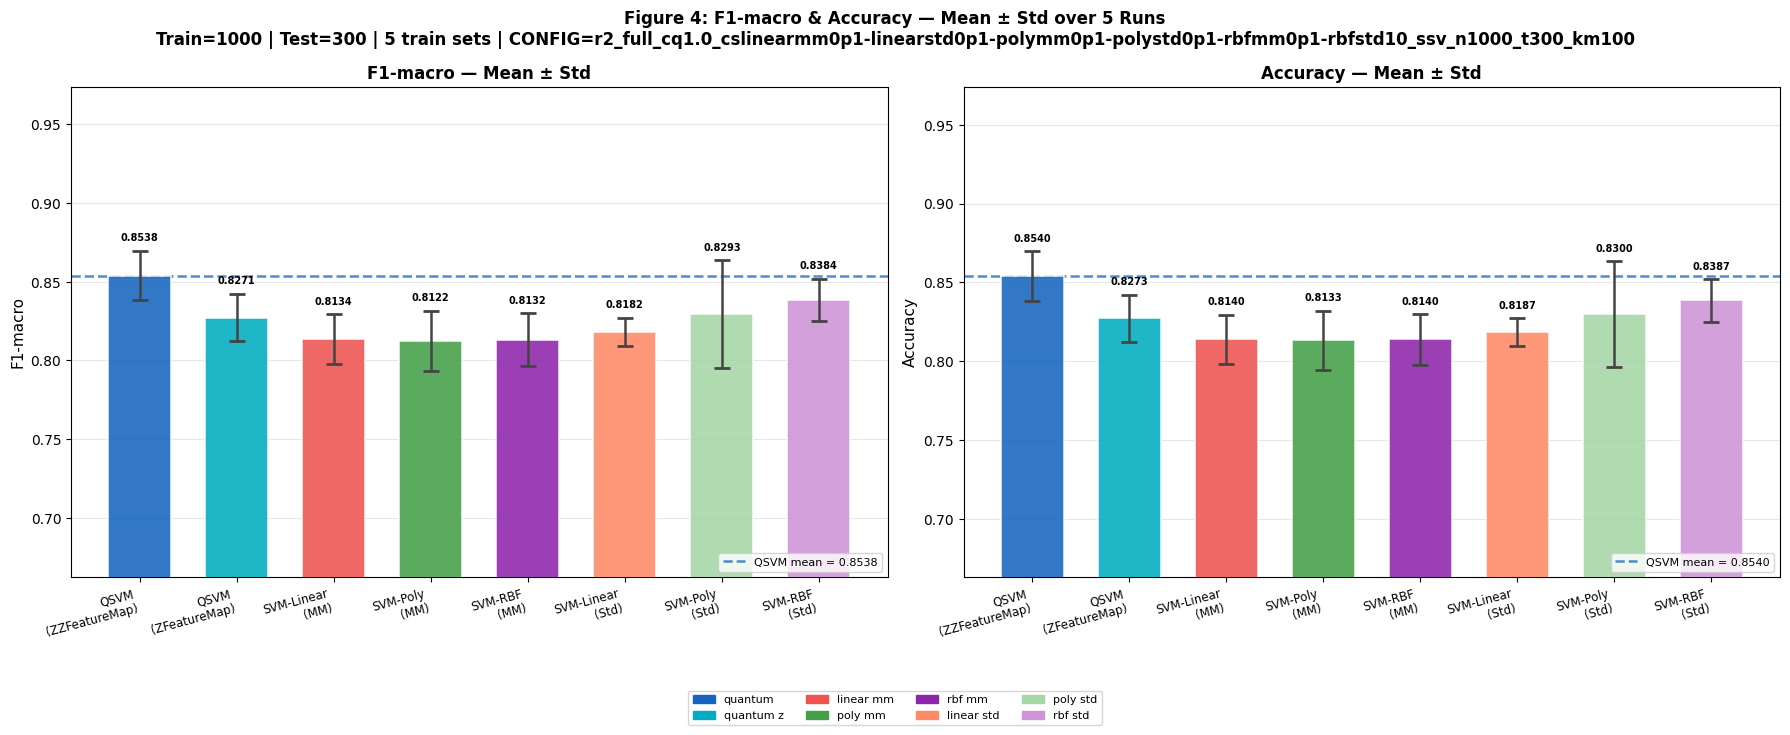

Đã lưu: ../results/c3_multirun/c3_multirun_f1_acc_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


In [113]:
MODEL_PALETTE = {
    'quantum'    : '#1565C0',
    'quantum_z'  : '#00ACC1',
    'linear_mm'  : '#EF5350',
    'linear_std' : '#FF8A65',
    'poly_mm'    : '#43A047',
    'poly_std'   : '#A5D6A7',
    'rbf_mm'     : '#8E24AA',
    'rbf_std'    : '#CE93D8',
}
SHORT_NAMES = {
    'quantum'    : 'QSVM\n(ZZFeatureMap)',
    'quantum_z'  : 'QSVM\n(ZFeatureMap)',
    'linear_mm'  : 'SVM-Linear\n(MM)',
    'poly_mm'    : 'SVM-Poly\n(MM)',
    'rbf_mm'     : 'SVM-RBF\n(MM)',
    'linear_std' : 'SVM-Linear\n(Std)',
    'poly_std'   : 'SVM-Poly\n(Std)',
    'rbf_std'    : 'SVM-RBF\n(Std)',
}
DISPLAY_ORDER = ['quantum', 'quantum_z', 'linear_mm', 'poly_mm', 'rbf_mm',
                 'linear_std', 'poly_std', 'rbf_std']

fig4, axes4 = plt.subplots(1, 2, figsize=(18, 7))
fig4.suptitle(
    f'Figure 4: F1-macro & Accuracy — Mean ± Std over {len(RUN_IDS)} Runs\n'
    f'Train={TRAIN_SIZE} | Test={TEST_SIZE} | {len(RUN_IDS)} train sets | CONFIG={CONFIG_TAG}',
    fontsize=12, fontweight='bold'
)

x   = np.arange(len(DISPLAY_ORDER))
bar_colors = [MODEL_PALETTE[k] for k in DISPLAY_ORDER]
bar_labels = [SHORT_NAMES[k]   for k in DISPLAY_ORDER]

for ax, metric, metric_label in [
    (axes4[0], 'f1',  'F1-macro'),
    (axes4[1], 'acc', 'Accuracy'),
]:
    means = [agg[agg['model_key']==k][f'mean_{metric}'].values[0] if not agg[agg['model_key']==k].empty else float('nan') for k in DISPLAY_ORDER]
    stds  = [agg[agg['model_key']==k][f'std_{metric}'].values[0]  if not agg[agg['model_key']==k].empty else float('nan') for k in DISPLAY_ORDER]

    bars = ax.bar(x, means, 0.65, yerr=stds, capsize=6,
                  color=bar_colors, alpha=0.88,
                  error_kw=dict(elinewidth=1.8, ecolor='#444', capthick=2),
                  edgecolor='white', linewidth=1.2, zorder=3)

    # QSVM reference line
    q_mean_val = agg[agg['model_key']=='quantum'][f'mean_{metric}'].values
    if len(q_mean_val):
        ax.axhline(q_mean_val[0], color=MODEL_PALETTE['quantum'],
                   linestyle='--', linewidth=1.8, alpha=0.75, zorder=2,
                   label=f'QSVM mean = {q_mean_val[0]:.4f}')
        ax.legend(fontsize=8, loc='lower right')

    for bar, mean_v, std_v in zip(bars, means, stds):
        if not np.isnan(mean_v):
            ax.text(bar.get_x() + bar.get_width()/2, mean_v + std_v + 0.005,
                    f'{mean_v:.4f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, fontsize=8.5, rotation=15, ha='right')
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f'{metric_label} — Mean ± Std', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, zorder=0)
    valid = [v for v in means if not np.isnan(v)]
    if valid:
        ax.set_ylim(max(0, min(valid)-0.15), min(1, max(valid)+0.12))

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(color=MODEL_PALETTE[k], label=k.replace('_',' ')) for k in DISPLAY_ORDER]
fig4.legend(handles=legend_elems, loc='lower center', ncol=4,
            fontsize=8, bbox_to_anchor=(0.5,-0.05), frameon=True)
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig4_path = f'{OUTPUT_DIR}/c3_multirun_f1_acc_{CONFIG_TAG}.png'
plt.savefig(fig4_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {fig4_path}')


## 7. Figure 5: KTA — Mean ± Std Bar Chart


Δ KTA (ZZ - Z)      : +0.134914
Δ KTA (ZZ - linear_std  ): +0.142511
Δ KTA (ZZ - poly_std    ): +0.079979
Δ KTA (ZZ - rbf_std     ): -0.042648


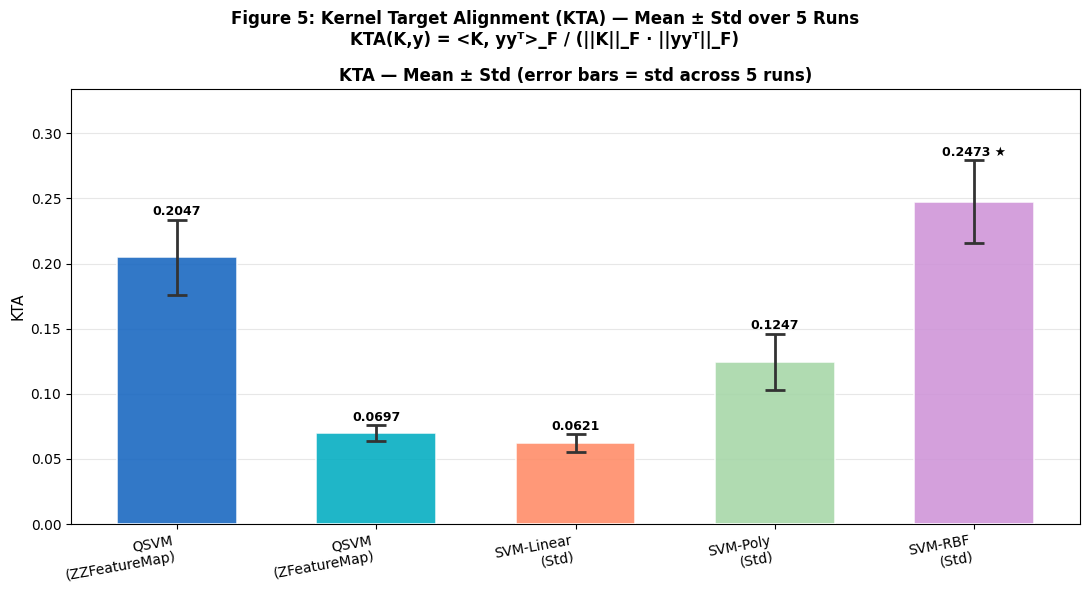


Đã lưu: ../results/c3_multirun/c3_multirun_kta_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


In [114]:
KTA_ORDER = ['quantum', 'quantum_z', 'linear_std', 'poly_std', 'rbf_std']
KTA_COLORS = [MODEL_PALETTE[k] for k in KTA_ORDER]
KTA_LABELS = [SHORT_NAMES[k]   for k in KTA_ORDER]

kta_means = [agg[agg['model_key']==k]['mean_kta'].values[0] if not agg[agg['model_key']==k].empty else float('nan') for k in KTA_ORDER]
kta_stds  = [agg[agg['model_key']==k]['std_kta'].values[0]  if not agg[agg['model_key']==k].empty else float('nan') for k in KTA_ORDER]

fig5, ax5 = plt.subplots(figsize=(11, 6))
fig5.suptitle(
    f'Figure 5: Kernel Target Alignment (KTA) — Mean ± Std over {len(RUN_IDS)} Runs\n'
    f'KTA(K,y) = <K, yyᵀ>_F / (||K||_F · ||yyᵀ||_F)',
    fontsize=12, fontweight='bold'
)
x5 = np.arange(len(KTA_ORDER))
bars5 = ax5.bar(x5, kta_means, 0.6, yerr=kta_stds, capsize=7,
                color=KTA_COLORS, alpha=0.88,
                error_kw=dict(elinewidth=2, ecolor='#333', capthick=2),
                edgecolor='white', linewidth=1.2, zorder=3)

best_idx = int(np.nanargmax(kta_means))
for idx, (bar, mean_v, std_v) in enumerate(zip(bars5, kta_means, kta_stds)):
    if not np.isnan(mean_v):
        star = ' ★' if idx == best_idx else ''
        ax5.text(bar.get_x()+bar.get_width()/2, mean_v+std_v+0.001,
                 f'{mean_v:.4f}{star}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax5.set_xticks(x5)
ax5.set_xticklabels(KTA_LABELS, fontsize=10, rotation=10, ha='right')
ax5.set_ylabel('KTA', fontsize=11)
ax5.set_title('KTA — Mean ± Std (error bars = std across 5 runs)', fontweight='bold')
ax5.grid(True, axis='y', alpha=0.3, zorder=0)
valid5 = [v for v in kta_means if not np.isnan(v)]
if valid5:
    ax5.set_ylim(0, max(valid5)*1.35)

# Δ KTA annotations
q_kta  = kta_means[KTA_ORDER.index('quantum')]
qz_kta = kta_means[KTA_ORDER.index('quantum_z')]
print(f'\nΔ KTA (ZZ - Z)      : {q_kta - qz_kta:+.6f}')
for k in ['linear_std','poly_std','rbf_std']:
    v = kta_means[KTA_ORDER.index(k)]
    print(f'Δ KTA (ZZ - {k:12s}): {q_kta - v:+.6f}')

plt.tight_layout()
fig5_path = f'{OUTPUT_DIR}/c3_multirun_kta_{CONFIG_TAG}.png'
plt.savefig(fig5_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nĐã lưu: {fig5_path}')


## 8. Figure 6: Support Vectors — Mean ± Std

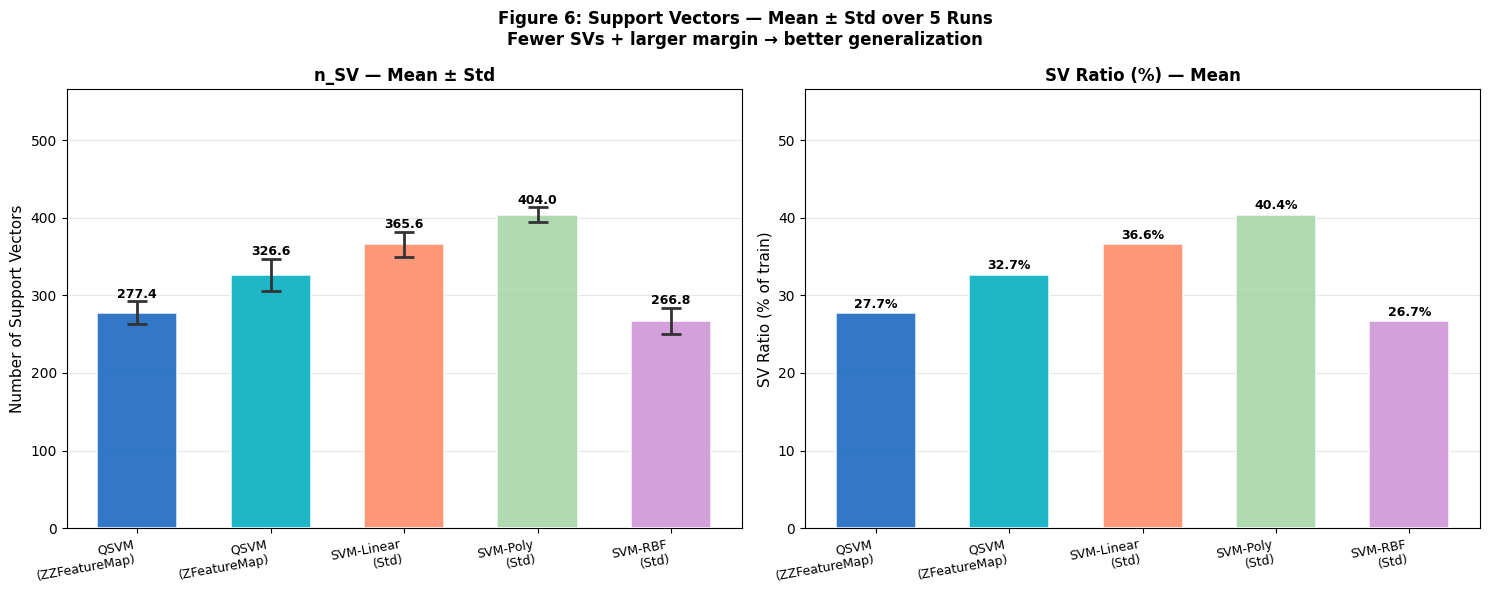

Đã lưu: ../results/c3_multirun/c3_multirun_nsv_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png

=== n_SV Summary  (train=1000) ===
         Model   n_SV mean    n_SV std     SV%
------------------------------------------------
       quantum       277.4        14.7   27.7%
     quantum_z       326.6        20.8   32.7%
    linear_std       365.6        16.4   36.6%
      poly_std       404.0         9.3   40.4%
       rbf_std       266.8        17.0   26.7%


In [115]:
NSV_ORDER  = ['quantum', 'quantum_z', 'linear_std', 'poly_std', 'rbf_std']
NSV_COLORS = [MODEL_PALETTE[k] for k in NSV_ORDER]
NSV_LABELS = [SHORT_NAMES[k]   for k in NSV_ORDER]

nsv_means  = [agg[agg['model_key']==k]['mean_nsv'].values[0] if not agg[agg['model_key']==k].empty else float('nan') for k in NSV_ORDER]
nsv_stds   = [agg[agg['model_key']==k]['std_nsv'].values[0]  if not agg[agg['model_key']==k].empty else float('nan') for k in NSV_ORDER]
svr_means  = [agg[agg['model_key']==k]['mean_svr'].values[0] if not agg[agg['model_key']==k].empty else float('nan') for k in NSV_ORDER]

fig6, axes6 = plt.subplots(1, 2, figsize=(15, 6))
fig6.suptitle(
    f'Figure 6: Support Vectors — Mean ± Std over {len(RUN_IDS)} Runs\n'
    f'Fewer SVs + larger margin → better generalization',
    fontsize=12, fontweight='bold'
)

x6 = np.arange(len(NSV_ORDER))

# Left: n_SV
bars6a = axes6[0].bar(x6, nsv_means, 0.6, yerr=nsv_stds, capsize=7,
                      color=NSV_COLORS, alpha=0.88,
                      error_kw=dict(elinewidth=2, ecolor='#333', capthick=2),
                      edgecolor='white', linewidth=1.2, zorder=3)
for bar, mean_v, std_v in zip(bars6a, nsv_means, nsv_stds):
    if not np.isnan(mean_v):
        axes6[0].text(bar.get_x()+bar.get_width()/2, mean_v+std_v+1,
                      f'{mean_v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes6[0].set_xticks(x6); axes6[0].set_xticklabels(NSV_LABELS, fontsize=9, rotation=10, ha='right')
axes6[0].set_ylabel('Number of Support Vectors', fontsize=11)
axes6[0].set_title('n_SV — Mean ± Std', fontweight='bold')
axes6[0].grid(True, axis='y', alpha=0.3, zorder=0)
valid6 = [v for v in nsv_means if not np.isnan(v)]
if valid6: axes6[0].set_ylim(0, max(valid6)*1.4)

# Right: SV ratio %
bars6b = axes6[1].bar(x6, [v*100 for v in svr_means], 0.6,
                      color=NSV_COLORS, alpha=0.88, edgecolor='white', linewidth=1.2, zorder=3)
for bar, mean_v in zip(bars6b, svr_means):
    if not np.isnan(mean_v):
        axes6[1].text(bar.get_x()+bar.get_width()/2, mean_v*100+0.3,
                      f'{mean_v*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes6[1].set_xticks(x6); axes6[1].set_xticklabels(NSV_LABELS, fontsize=9, rotation=10, ha='right')
axes6[1].set_ylabel('SV Ratio (% of train)', fontsize=11)
axes6[1].set_title('SV Ratio (%) — Mean', fontweight='bold')
axes6[1].grid(True, axis='y', alpha=0.3, zorder=0)
axes6[1].set_ylim(0, max([v*100 for v in svr_means if not np.isnan(v)])*1.4 if valid6 else 1)

plt.tight_layout()
fig6_path = f'{OUTPUT_DIR}/c3_multirun_nsv_{CONFIG_TAG}.png'
plt.savefig(fig6_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {fig6_path}')

# Print summary table
print()
print(f'=== n_SV Summary  (train={TRAIN_SIZE}) ===')
print(f'{"Model":>14}  {"n_SV mean":>10}  {"n_SV std":>10}  {"SV%":>6}')
print('-'*48)
for key, mean_v, std_v, svr in zip(NSV_ORDER, nsv_means, nsv_stds, svr_means):
    print(f'{key:>14}  {mean_v:>10.1f}  {std_v:>10.1f}  {svr*100:>5.1f}%')


## 9. Figure 7: Per-Run F1 Trend Lines

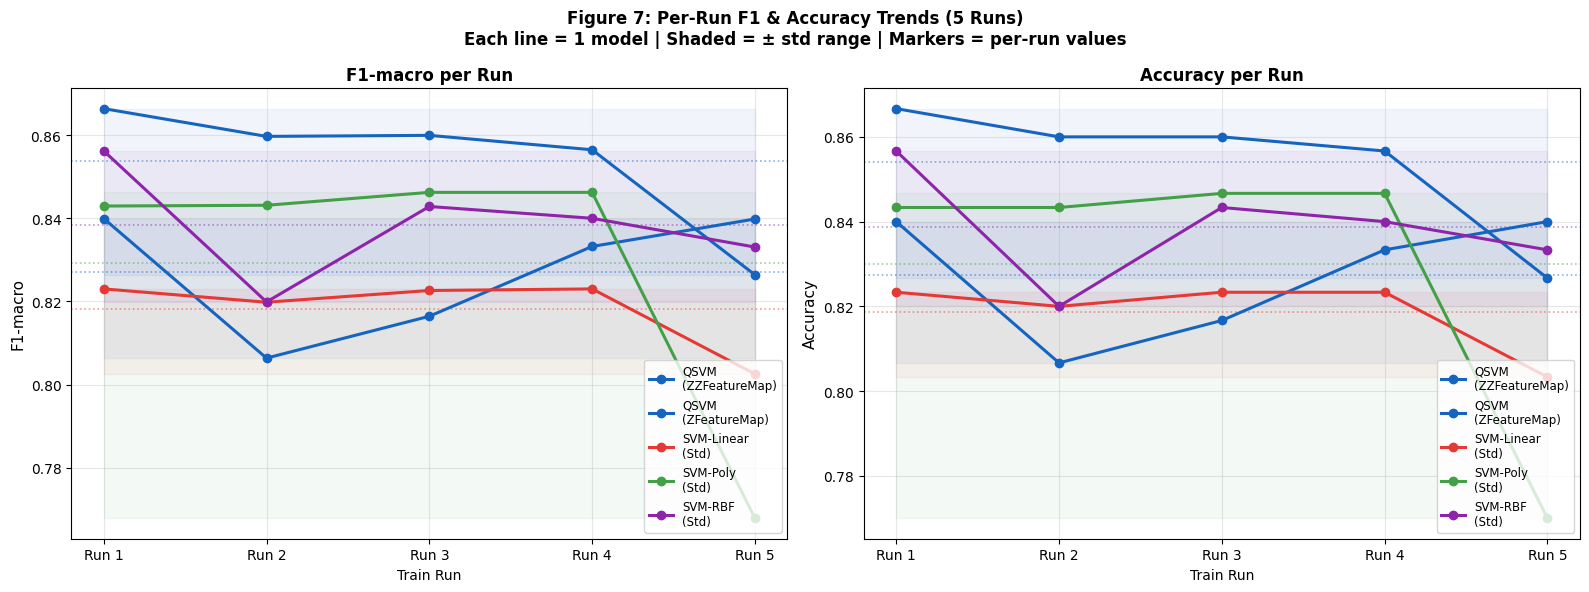

Đã lưu: ../results/c3_multirun/c3_multirun_trend_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


In [116]:
# Models to show in trend plot (representative subset)
TREND_KEYS = ['quantum', 'quantum_z', 'linear_std', 'poly_std', 'rbf_std']
TREND_COLORS = {k: COLORS.get(k.split('_')[0], MODEL_PALETTE.get(k, '#888')) for k in TREND_KEYS}
TREND_LABELS = {k: SHORT_NAMES[k].replace('\\n', ' ') for k in TREND_KEYS}

fig7, axes7 = plt.subplots(1, 2, figsize=(16, 6))
fig7.suptitle(
    f'Figure 7: Per-Run F1 & Accuracy Trends ({len(RUN_IDS)} Runs)\n'
    f'Each line = 1 model | Shaded = ± std range | Markers = per-run values',
    fontsize=12, fontweight='bold'
)

for ax, metric, ylabel in [(axes7[0], 'f1_macro', 'F1-macro'), (axes7[1], 'accuracy', 'Accuracy')]:
    for key in TREND_KEYS:
        vals = per_run_df[per_run_df['model_key'] == key].sort_values('run_id')[metric].values
        runs = per_run_df[per_run_df['model_key'] == key].sort_values('run_id')['run_id'].values
        color = TREND_COLORS[key]
        ax.plot(runs, vals, marker='o', linewidth=2.2, color=color,
                label=TREND_LABELS[key], zorder=4)
        mean_v = vals.mean()
        ax.axhline(mean_v, color=color, linestyle=':', linewidth=1.2, alpha=0.5, zorder=2)
        ax.fill_between(runs, vals.min(), vals.max(), color=color, alpha=0.06, zorder=1)

    ax.set_xticks(RUN_IDS)
    ax.set_xticklabels([f'Run {r}' for r in RUN_IDS], fontsize=10)
    ax.set_xlabel('Train Run', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel} per Run', fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend(fontsize=8.5, loc='lower right')

plt.tight_layout()
fig7_path = f'{OUTPUT_DIR}/c3_multirun_trend_{CONFIG_TAG}.png'
plt.savefig(fig7_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {fig7_path}')


## 10. Figures 1, 2, 3 — Representative Run (Giống Notebook Gốc)

Toàn bộ visualizations từ notebook gốc được vẽ lại cho representative run.

### 10a. Load Representative Run Artifacts

Chọn một run đại diện để tái dựng các visualization chi tiết giống notebook gốc, trong khi các metric chính vẫn báo cáo theo multi-run.


In [117]:
# ── Load representative run artifacts ────────────────────────────────────
rep      = all_artifacts[REPRESENTATIVE_RUN_ID]
X_train  = rep['X_train']
y_train  = rep['y_train']
X_train_std = rep.get('X_train_std')
if X_train_std is None:
    # Backward-compatible fallback for artifacts created before X_train_std was stored.
    X_train_std = StandardScaler().fit_transform(rep['X_train_pca'])
X_km     = rep['X_km']
y_km     = rep['y_km']
km_matrices = rep['km_matrices']
kta_scores  = rep['kta_scores']
sv_analysis = {k: rep['metrics'][k] for k in rep['metrics']}
qsvm_model  = rep['models']['quantum']
qsvm_z_model= rep['models']['quantum_z']
svm_models  = {k: v for k, v in rep['models'].items() if k not in ('quantum','quantum_z')}

qsvm_result  = rep['metrics']['quantum']
qsvm_z_result= rep['metrics']['quantum_z']
svm_results  = {k: rep['metrics'][k] for k in rep['metrics'] if k not in ('quantum','quantum_z')}
pearson_mat  = rep['pearson_mat']
spearman_mat = rep['spearman_mat']

sort_idx = np.argsort(y_km)
y_km_s   = y_km[sort_idx]
boundary = int(np.where(np.diff(y_km_s))[0][0]) + 1

print(f'Representative run: {REPRESENTATIVE_RUN_ID}')
print(f'X_train: {X_train.shape} | X_km: {X_km.shape}')


Representative run: 4
X_train: (1000, 4) | X_km: (100, 4)


### 10b. Spearman Correlation Validation — Representative Run

Vẽ Pearson, Spearman và non-linear excess cho từng cặp PC để kiểm tra tín hiệu tương quan phi tuyến mà ZZFeatureMap có thể khai thác.


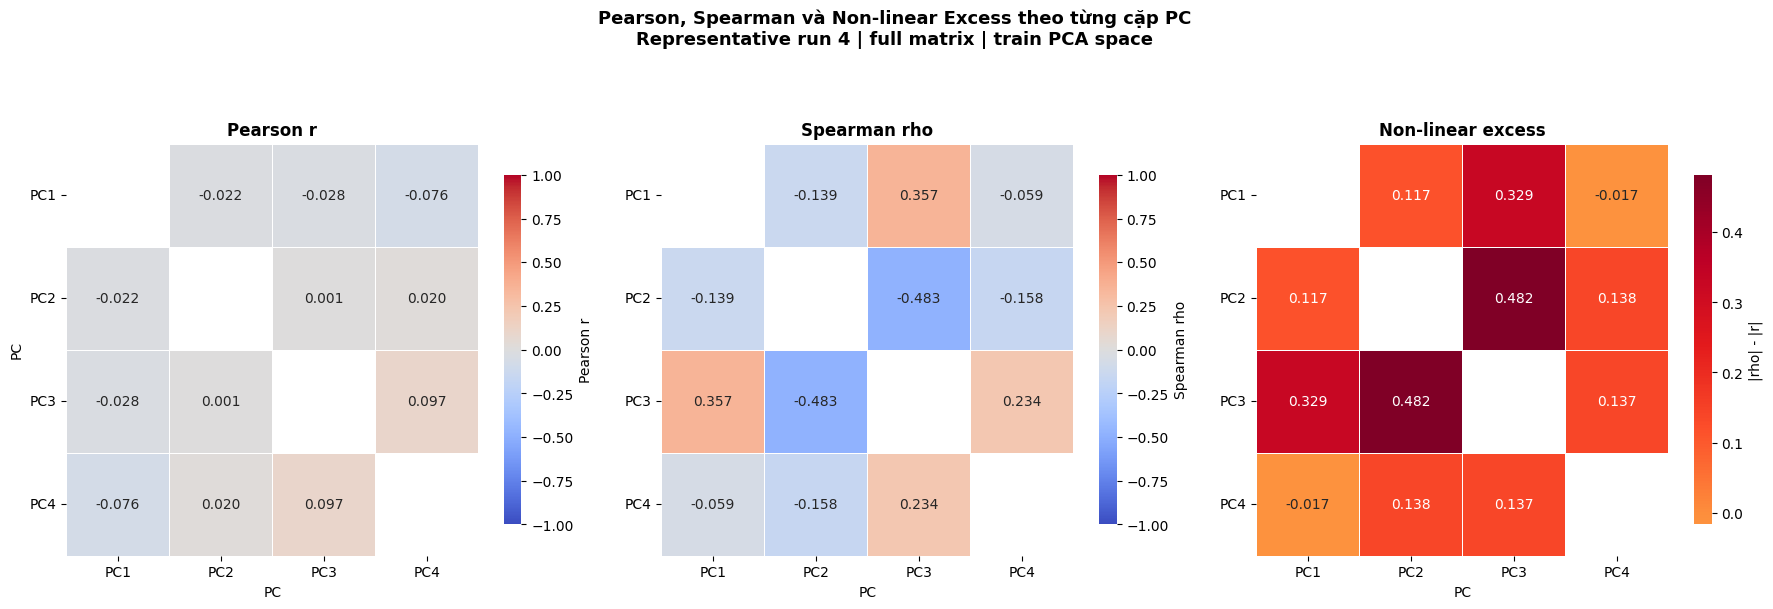

Đã lưu combined heatmap: ../results/c3_multirun/c3_reprun4_pc_pair_corr_heatmaps_combined_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


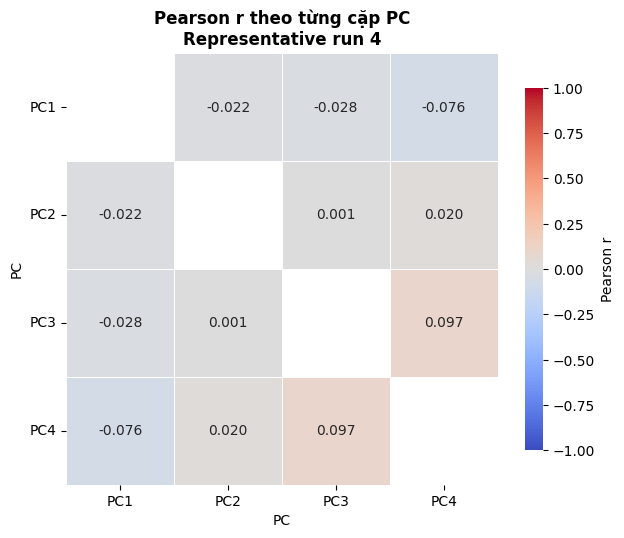

Đã lưu pearson heatmap: ../results/c3_multirun/c3_reprun4_pc_pair_pearson_heatmap_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


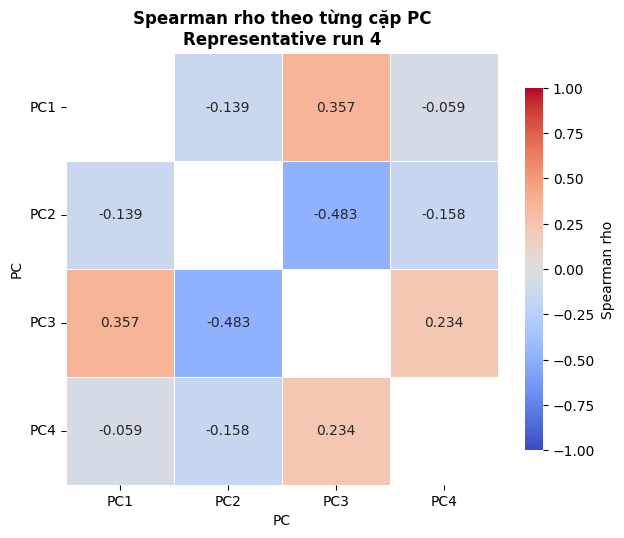

Đã lưu spearman heatmap: ../results/c3_multirun/c3_reprun4_pc_pair_spearman_heatmap_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


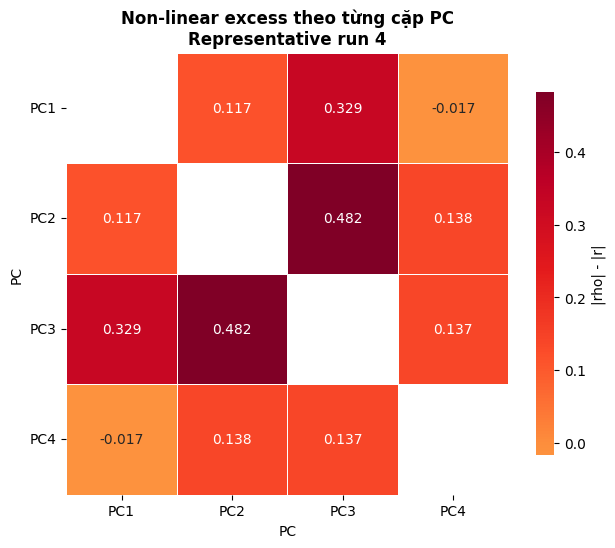

Đã lưu nonlinear_excess heatmap: ../results/c3_multirun/c3_reprun4_pc_pair_nonlinear_excess_heatmap_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


In [118]:
# ════════════════════════════════════════════════════════════════════════
# EXTRA FIGURE: Pearson / Spearman / Non-linear Excess heatmaps cho từng cặp PC
# Representative run only
# ════════════════════════════════════════════════════════════════════════
pearson_rep = np.asarray(rep['pearson_mat'], dtype=float).copy()
spearman_rep = np.asarray(rep['spearman_mat'], dtype=float).copy()
excess_rep = np.abs(spearman_rep) - np.abs(pearson_rep)

for mat in [pearson_rep, spearman_rep, excess_rep]:
    np.fill_diagonal(mat, np.nan)

tri_vals = lambda mat: mat[~np.eye(mat.shape[0], dtype=bool)]

corr_heatmaps = [
    {
        'name': 'pearson',
        'title': 'Pearson r',
        'mat': pearson_rep,
        'cmap': 'coolwarm',
        'vmin': -1,
        'vmax': 1,
        'cbar_label': 'Pearson r',
    },
    {
        'name': 'spearman',
        'title': 'Spearman rho',
        'mat': spearman_rep,
        'cmap': 'coolwarm',
        'vmin': -1,
        'vmax': 1,
        'cbar_label': 'Spearman rho',
    },
    {
        'name': 'nonlinear_excess',
        'title': 'Non-linear excess',
        'mat': excess_rep,
        'cmap': 'YlOrRd',
        'vmin': min(0, np.nanmin(tri_vals(excess_rep))),
        'vmax': max(0.05, np.nanmax(tri_vals(excess_rep))),
        'cbar_label': '|rho| - |r|',
    },
]

def _annot_values(mat):
    annot = np.empty(mat.shape, dtype=object)
    annot[:] = ''
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if i != j and np.isfinite(mat[i, j]):
                annot[i, j] = f'{mat[i, j]:.3f}'
    return annot

def _draw_pc_corr_heatmap(ax, cfg, show_ylabel=True):
    sns.heatmap(
        cfg['mat'],
        annot=_annot_values(cfg['mat']),
        fmt='',
        cmap=cfg['cmap'],
        vmin=cfg['vmin'],
        vmax=cfg['vmax'],
        center=0 if cfg['vmin'] < 0 < cfg['vmax'] else None,
        square=True,
        linewidths=0.6,
        linecolor='white',
        xticklabels=PC_LABELS,
        yticklabels=PC_LABELS,
        ax=ax,
        cbar_kws={'label': cfg['cbar_label'], 'shrink': 0.82},
        annot_kws={'fontsize': 10},
    )
    ax.set_title(cfg['title'], fontweight='bold', fontsize=12)
    ax.set_xlabel('PC', fontsize=10)
    ax.set_ylabel('PC' if show_ylabel else '', fontsize=10)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

# ── Combined 3-panel heatmap ────────────────────────────────────────────────
fig_pc_heat, axes_pc_heat = plt.subplots(1, 3, figsize=(18, 5.8))
fig_pc_heat.suptitle(
    f'Pearson, Spearman và Non-linear Excess theo từng cặp PC\n'
    f'Representative run {REPRESENTATIVE_RUN_ID} | full matrix | train PCA space',
    fontsize=13,
    fontweight='bold',
)

for idx_hm, cfg in enumerate(corr_heatmaps):
    _draw_pc_corr_heatmap(axes_pc_heat[idx_hm], cfg, show_ylabel=(idx_hm == 0))

plt.tight_layout(rect=[0, 0, 1, 0.88])
fig_pc_heat_path = f'{OUTPUT_DIR}/c3_reprun{REPRESENTATIVE_RUN_ID}_pc_pair_corr_heatmaps_combined_{CONFIG_TAG}.png'
plt.savefig(fig_pc_heat_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu combined heatmap: {fig_pc_heat_path}')

# ── Save each heatmap separately ─────────────────────────────────────────────
for cfg in corr_heatmaps:
    fig_single, ax_single = plt.subplots(figsize=(6.4, 5.4))
    _draw_pc_corr_heatmap(ax_single, cfg, show_ylabel=True)
    ax_single.set_title(
        f'{cfg["title"]} theo từng cặp PC\nRepresentative run {REPRESENTATIVE_RUN_ID}',
        fontweight='bold',
        fontsize=12,
    )
    plt.tight_layout()
    single_path = f'{OUTPUT_DIR}/c3_reprun{REPRESENTATIVE_RUN_ID}_pc_pair_{cfg["name"]}_heatmap_{CONFIG_TAG}.png'
    plt.savefig(single_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Đã lưu {cfg["name"]} heatmap: {single_path}')


### 10c. Figure 1 — Visualization Tổng Hợp: Overview

Tái dựng overview từ notebook gốc cho representative run: kernel structure, KTA, support vectors, decision boundary và correlation excess.


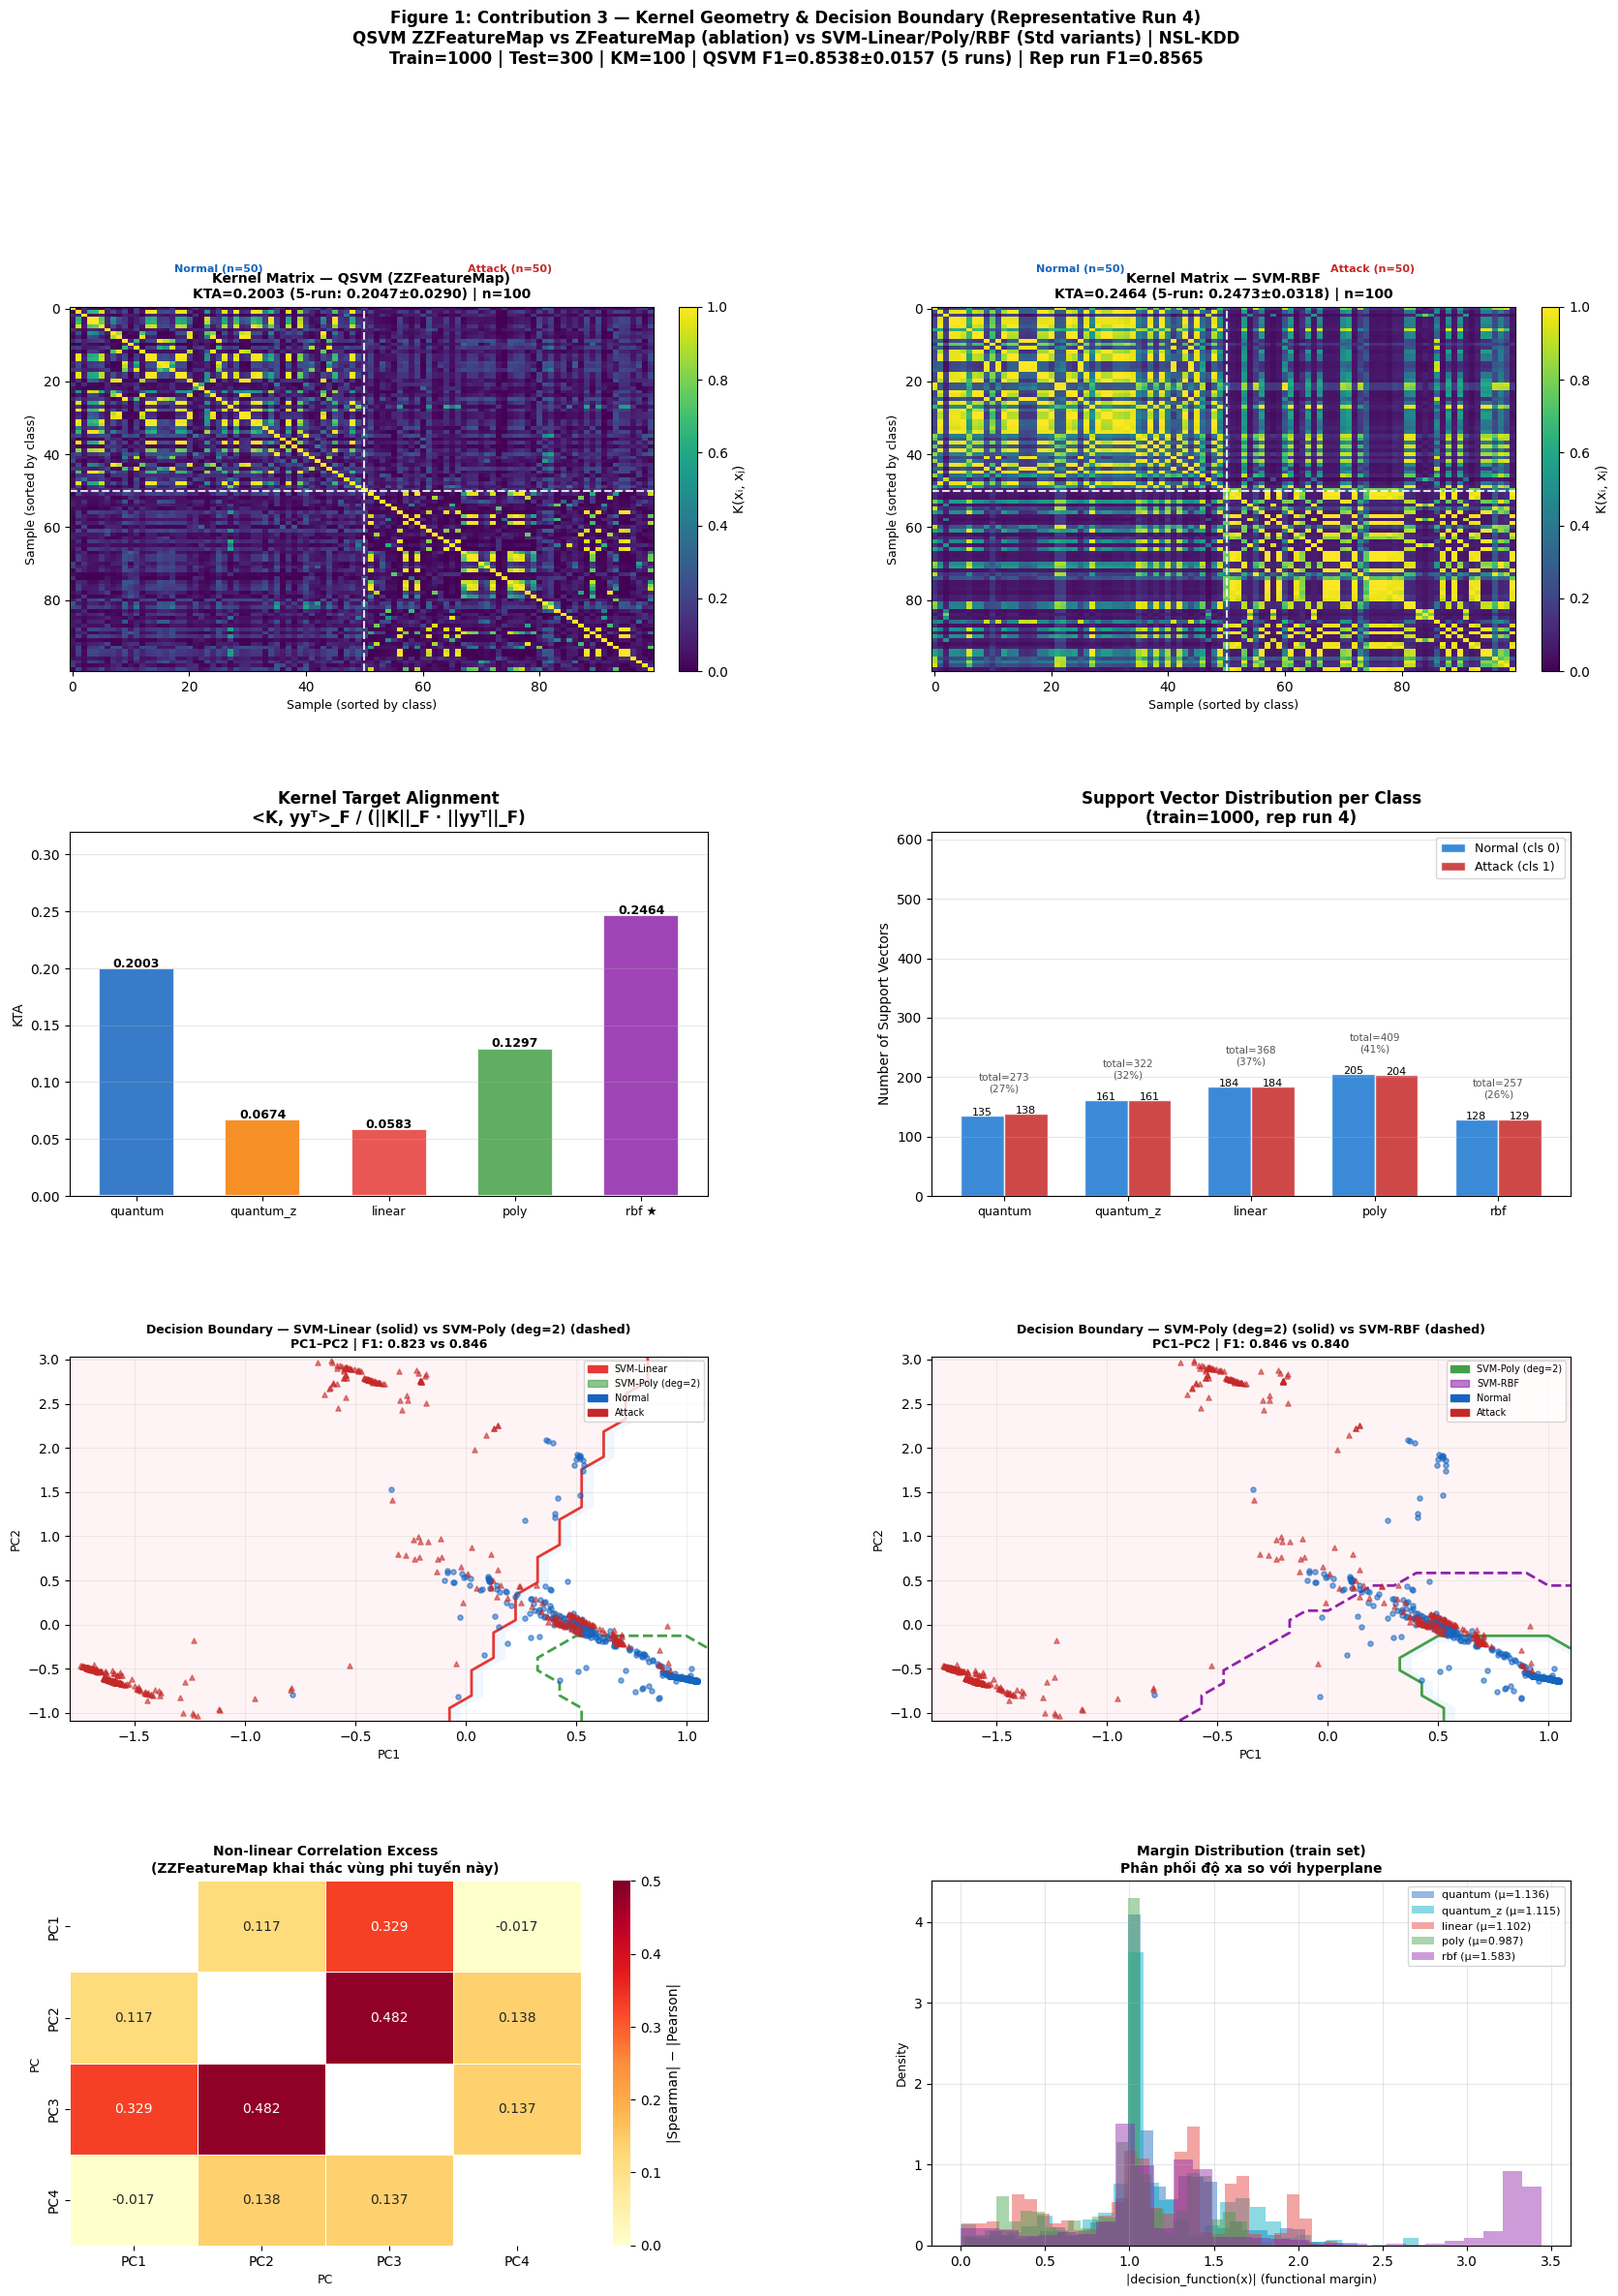

Đã lưu Figure 1: ../results/c3_multirun/c3_multirun_fig1_overview_run4_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


In [119]:
# ════════════════════════════════════════════════════════════════════════
# FIGURE 1: Overview (8 panels) — identical structure to original C3
# ════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 26))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.44, wspace=0.35)

# Mean ± std strings for subtitle
q_f1_mean = agg[agg['model_key']=='quantum']['mean_f1'].values[0]
q_f1_std  = agg[agg['model_key']=='quantum']['std_f1'].values[0]

fig.suptitle(
    f'Figure 1: Contribution 3 — Kernel Geometry & Decision Boundary (Representative Run {REPRESENTATIVE_RUN_ID})\n'
    f'QSVM ZZFeatureMap vs ZFeatureMap (ablation) vs SVM-Linear/Poly/RBF (Std variants) | NSL-KDD\n'
    f'Train={TRAIN_SIZE} | Test={TEST_SIZE} | KM={KM_SAMPLE_SIZE} | '
    f'QSVM F1={q_f1_mean:.4f}±{q_f1_std:.4f} (5 runs) | Rep run F1={qsvm_result["f1"]:.4f}',
    fontsize=12, fontweight='bold', y=0.998
)

# ── Row 1: Kernel heatmaps — Quantum ZZ vs RBF ───────────────────────────
for col_idx, km_lbl in enumerate(['quantum', 'rbf']):
    ax   = fig.add_subplot(gs[0, col_idx])
    K    = km_matrices[km_lbl][sort_idx][:, sort_idx]
    im   = ax.imshow(K, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    ax.axhline(boundary, color='white', lw=1.5, ls='--', alpha=0.85)
    ax.axvline(boundary, color='white', lw=1.5, ls='--', alpha=0.85)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='K(xᵢ, xⱼ)')
    kta_v    = kta_scores.get(km_lbl, float('nan'))
    kta_mean = agg[agg['model_key']==(km_lbl if km_lbl in ['quantum','quantum_z'] else f'{km_lbl}_std')]['mean_kta'].values
    kta_std  = agg[agg['model_key']==(km_lbl if km_lbl in ['quantum','quantum_z'] else f'{km_lbl}_std')]['std_kta'].values
    kta_multi= f' (5-run: {kta_mean[0]:.4f}±{kta_std[0]:.4f})' if len(kta_mean) else ''
    ax.set_title(f'Kernel Matrix — {LABEL_NAMES[km_lbl]}\nKTA={kta_v:.4f}{kta_multi} | n={KM_SAMPLE_SIZE}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Sample (sorted by class)', fontsize=9)
    ax.set_ylabel('Sample (sorted by class)', fontsize=9)
    n0 = int(np.sum(y_km_s == 0)); n1 = int(np.sum(y_km_s == 1))
    ax.text(n0//2,      -10, f'Normal (n={n0})',  ha='center', fontsize=8, color='#1565C0', fontweight='bold', clip_on=False)
    ax.text(n0+n1//2,   -10, f'Attack (n={n1})',  ha='center', fontsize=8, color='#C62828', fontweight='bold', clip_on=False)

# ── Row 2: KTA bar + SV distribution ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
kta_lbs = ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']
kta_vs  = [kta_scores.get(l, float('nan')) for l in kta_lbs]
bars    = ax3.bar(kta_lbs, kta_vs, color=[COLORS[l] for l in kta_lbs],
                  alpha=0.85, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, kta_vs):
    if not np.isnan(val):
        ax3.text(bar.get_x()+bar.get_width()/2, val+0.001, f'{val:.4f}',
                 ha='center', fontsize=9, fontweight='bold')
_best = kta_lbs[int(np.nanargmax(kta_vs))]
ax3.set_xticklabels([f'{l} ★' if l == _best else l for l in kta_lbs], fontsize=9)
ax3.set_ylabel('KTA', fontsize=10)
ax3.set_title('Kernel Target Alignment\n<K, yyᵀ>_F / (||K||_F · ||yyᵀ||_F)', fontweight='bold')
ax3.set_ylim(0, max(v for v in kta_vs if not np.isnan(v))*1.30)
ax3.grid(True, axis='y', alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
sv_lb = [l for l in ['quantum','quantum_z','linear_std','poly_std','rbf_std'] if l in sv_analysis]
sv_display = ['quantum','quantum_z','linear','poly','rbf']
sv_n0 = [sv_analysis[k]['sv_class_dist'][0] for k in sv_lb]
sv_n1 = [sv_analysis[k]['sv_class_dist'][1] for k in sv_lb]
sv_nt = [sv_analysis[k]['n_sv']             for k in sv_lb]
x_sv  = np.arange(len(sv_lb)); w_sv = 0.35
b0 = ax4.bar(x_sv-w_sv/2, sv_n0, w_sv, label='Normal (cls 0)', color='#1976D2', alpha=0.85, edgecolor='white')
b1 = ax4.bar(x_sv+w_sv/2, sv_n1, w_sv, label='Attack (cls 1)', color='#C62828', alpha=0.85, edgecolor='white')
for bar, val in zip(list(b0)+list(b1), sv_n0+sv_n1):
    ax4.text(bar.get_x()+bar.get_width()/2, val+0.3, str(val), ha='center', fontsize=8)
for i, (tot, pct) in enumerate(zip(sv_nt, [t/TRAIN_SIZE*100 for t in sv_nt])):
    ax4.text(i, max(sv_n0[i], sv_n1[i])+max(sv_nt)*0.09,
             f'total={tot}\n({pct:.0f}%)', ha='center', fontsize=7.5, color='#555')
ax4.set_xticks(x_sv)
ax4.set_xticklabels([k.replace('_std','') for k in sv_lb], fontsize=9)
ax4.set_ylabel('Number of Support Vectors', fontsize=10)
ax4.set_title(f'Support Vector Distribution per Class\n(train={TRAIN_SIZE}, rep run {REPRESENTATIVE_RUN_ID})', fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(True, axis='y', alpha=0.3)
ax4.set_ylim(0, max(sv_nt)*1.5)

# ── Row 3: Std-SVM decision boundaries in StandardScaler(PCA) space ───────
PC_PAIR_INFO = [('pc12',0,1,'PC1','PC2'), ('pc34',2,3,'PC3','PC4')]
model_dict_db = {
    'quantum':   qsvm_model,
    'quantum_z': qsvm_z_model,
    'linear':    svm_models.get('linear_std'),
    'poly':      svm_models.get('poly_std'),
    'rbf':       svm_models.get('rbf_std'),
}
pairs_row3 = [('linear','poly'), ('poly','rbf')]
for col_idx, (lbl_a, lbl_b) in enumerate(pairs_row3):
    ax = fig.add_subplot(gs[2, col_idx])
    _pair, _i, _j, _xl, _yl = PC_PAIR_INFO[0]
    for _lbl, _ls, _af in [(lbl_a,'solid',0.22),(lbl_b,'dashed',0.0)]:
        m = model_dict_db.get(_lbl)
        if m is None: continue
        _batch = 25 if 'quantum' in _lbl else 500
        _X_db = X_train if 'quantum' in _lbl else X_train_std
        xx, yy, Z = boundary_grid_fast(_X_db, m, (_i,_j), 30, _batch)
        if _af > 0:
            ax.contourf(xx, yy, Z, alpha=_af, levels=[-0.5,0.5,1.5], colors=['#BBDEFB','#FFCDD2'])
        ax.contour(xx, yy, Z, levels=[0.5], colors=[COLORS[_lbl]], linewidths=2.0, linestyles=_ls)
    for cls, marker, color in [(0,'o','#1565C0'),(1,'^','#C62828')]:
        mask = y_train == cls
        ax.scatter(_X_db[mask,_i], _X_db[mask,_j], c=color, marker=marker, s=14, alpha=0.55, zorder=3)
    f1_a = svm_results.get(f'{lbl_a}_std', qsvm_result if lbl_a=='quantum' else {}).get('f1', float('nan'))
    f1_b = svm_results.get(f'{lbl_b}_std', {}).get('f1', float('nan'))
    handles_db = [
        mpatches.Patch(color=COLORS[lbl_a], label=LABEL_NAMES[lbl_a]),
        mpatches.Patch(color=COLORS[lbl_b], label=LABEL_NAMES[lbl_b], alpha=0.6),
        mpatches.Patch(color='#1565C0', label='Normal'),
        mpatches.Patch(color='#C62828', label='Attack'),
    ]
    ax.legend(handles=handles_db, fontsize=7, loc='upper right')
    ax.set_title(f'Decision Boundary — {LABEL_NAMES[lbl_a]} (solid) vs {LABEL_NAMES[lbl_b]} (dashed)\n'
                 f'{_xl}–{_yl} | F1: {f1_a:.3f} vs {f1_b:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel(_xl, fontsize=9); ax.set_ylabel(_yl, fontsize=9)
    ax.grid(True, alpha=0.2)

# ── Row 4: Spearman delta + Margin distribution ────────────────────────────
ax_sp = fig.add_subplot(gs[3, 0])
delta_corr = np.abs(spearman_mat) - np.abs(pearson_mat)
np.fill_diagonal(delta_corr, 0)
sns.heatmap(delta_corr, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=max(0.5, delta_corr.max()),
            xticklabels=PC_LABELS, yticklabels=PC_LABELS,
            linewidths=0.5, mask=np.eye(N_QUBITS, dtype=bool), ax=ax_sp,
            cbar_kws={'label': '|Spearman| − |Pearson|'})
ax_sp.set_title('Non-linear Correlation Excess\n(ZZFeatureMap khai thác vùng phi tuyến này)',
                fontweight='bold', fontsize=10)
ax_sp.set_xlabel('PC', fontsize=9); ax_sp.set_ylabel('PC', fontsize=9)

ax_mg = fig.add_subplot(gs[3, 1])
mg_colors_full = {'quantum':'#1565C0','quantum_z':'#00ACC1','linear_std':'#E53935','poly_std':'#43A047','rbf_std':'#8E24AA'}
for lbl, color in mg_colors_full.items():
    info = sv_analysis.get(lbl, {})
    df_v = info.get('df_scores', np.array([]))
    if len(df_v) == 0: continue
    scores = np.abs(df_v)
    ax_mg.hist(scores, bins=30, alpha=0.45, color=color,
               label=f'{lbl.replace("_std","")} (μ={info["margin_mean"]:.3f})',
               density=True, edgecolor='none')
ax_mg.set_xlabel('|decision_function(x)| (functional margin)', fontsize=9)
ax_mg.set_ylabel('Density', fontsize=9)
ax_mg.set_title('Margin Distribution (train set)\nPhân phối độ xa so với hyperplane',
                fontweight='bold', fontsize=10)
ax_mg.legend(fontsize=8); ax_mg.grid(True, alpha=0.3)

plt.tight_layout()
fig1_path = f'{OUTPUT_DIR}/c3_multirun_fig1_overview_run{REPRESENTATIVE_RUN_ID}_{CONFIG_TAG}.png'
plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu Figure 1: {fig1_path}')


### 10d. Figure 2 — Decision Boundary: Kernels × PC Pairs

So sánh biên quyết định của quantum/classical kernels trên các cặp PC đại diện.


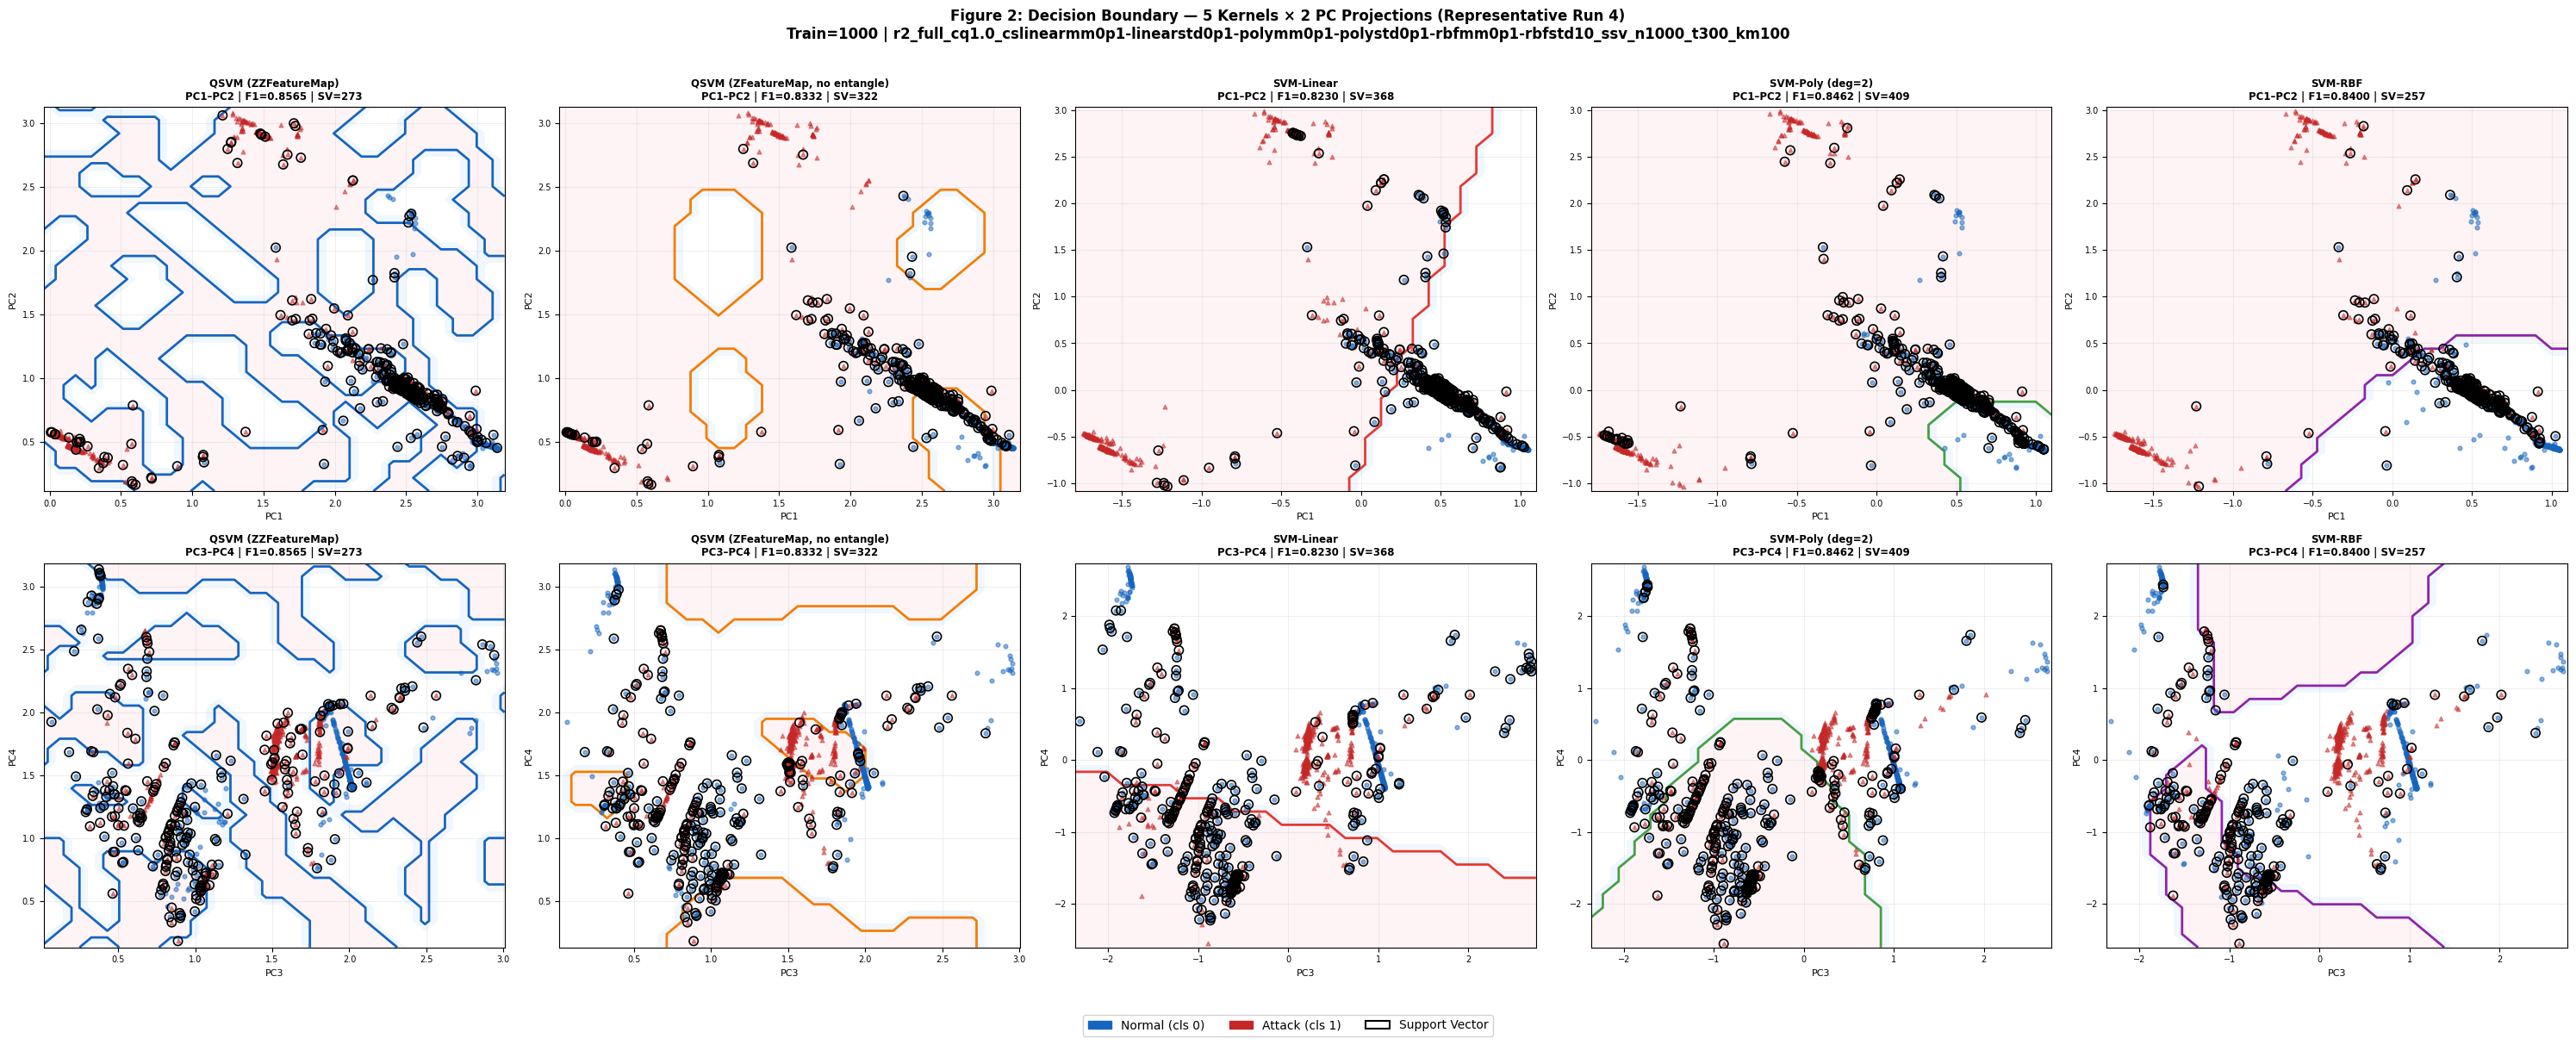

Đã lưu Figure 2: ../results/c3_multirun/c3_multirun_fig2_decision_run4_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


In [120]:
# ════════════════════════════════════════════════════════════════════════
# FIGURE 2: Decision Boundary — 5 kernels × 2 PC pairs (Full Grid)
# ════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 5, figsize=(30, 12))
fig2.suptitle(
    f'Figure 2: Decision Boundary — 5 Kernels × 2 PC Projections (Representative Run {REPRESENTATIVE_RUN_ID})\n'
    f'Train={TRAIN_SIZE} | {CONFIG_TAG}',
    fontsize=12, fontweight='bold'
)

ALL_LABELS_DB = ['quantum', 'quantum_z', 'linear', 'poly', 'rbf']
MODEL_DICT_ALL = {
    'quantum':   qsvm_model,
    'quantum_z': qsvm_z_model,
    'linear':    svm_models.get('linear_std'),
    'poly':      svm_models.get('poly_std'),
    'rbf':       svm_models.get('rbf_std'),
}

for col_idx, lbl in enumerate(ALL_LABELS_DB):
    for row_idx, (pname, _i, _j, xl, yl) in enumerate(PC_PAIR_INFO):
        ax = axes2[row_idx, col_idx]
        m  = MODEL_DICT_ALL.get(lbl)
        if m is None:
            ax.text(0.5,0.5,f'{lbl}\nnot available',ha='center',va='center',transform=ax.transAxes); continue
        _batch = 25 if 'quantum' in lbl else 500
        _X_db = X_train if 'quantum' in lbl else X_train_std
        xx, yy, Z = boundary_grid_fast(_X_db, m, (_i,_j), 30, _batch)
        ax.contourf(xx, yy, Z, alpha=0.22, levels=[-0.5,0.5,1.5], colors=['#BBDEFB','#FFCDD2'])
        ax.contour(xx, yy, Z, levels=[0.5], colors=[COLORS[lbl]], linewidths=2.0)
        for cls, marker, color in [(0,'o','#1565C0'),(1,'^','#C62828')]:
            mask = y_train == cls
            ax.scatter(_X_db[mask,_i], _X_db[mask,_j], c=color, marker=marker, s=12, alpha=0.5, zorder=3)
        if hasattr(m, 'support_'):
            sv_i = m.support_
            ax.scatter(_X_db[sv_i,_i], _X_db[sv_i,_j], s=55,
                       facecolors='none', edgecolors='black', linewidths=1.2, zorder=4)
        model_key = lbl if lbl in ('quantum','quantum_z') else f'{lbl}_std'
        f1_v = rep['metrics'].get(model_key, {}).get('f1', float('nan'))
        nsv  = rep['metrics'].get(model_key, {}).get('n_sv', 'N/A')
        ax.set_title(f'{LABEL_NAMES.get(lbl,lbl)}\n{xl}–{yl} | F1={f1_v:.4f} | SV={nsv}',
                     fontsize=8.5, fontweight='bold')
        ax.set_xlabel(xl, fontsize=8); ax.set_ylabel(yl, fontsize=8)
        ax.tick_params(labelsize=7); ax.grid(True, alpha=0.2)

leg_handles2 = [
    mpatches.Patch(color='#1565C0',  label='Normal (cls 0)'),
    mpatches.Patch(color='#C62828',  label='Attack (cls 1)'),
    mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, label='Support Vector'),
]
fig2.legend(handles=leg_handles2, loc='lower center', ncol=3, fontsize=10,
            bbox_to_anchor=(0.5,-0.02), framealpha=0.9)
plt.tight_layout(rect=[0,0.03,1,0.97])
fig2_path = f'{OUTPUT_DIR}/c3_multirun_fig2_decision_run{REPRESENTATIVE_RUN_ID}_{CONFIG_TAG}.png'
plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu Figure 2: {fig2_path}')


### 10e. Figure 3 — Kernel Gram Matrices

Hiển thị cấu trúc Gram matrix của các kernel trên representative run để quan sát block structure theo class.


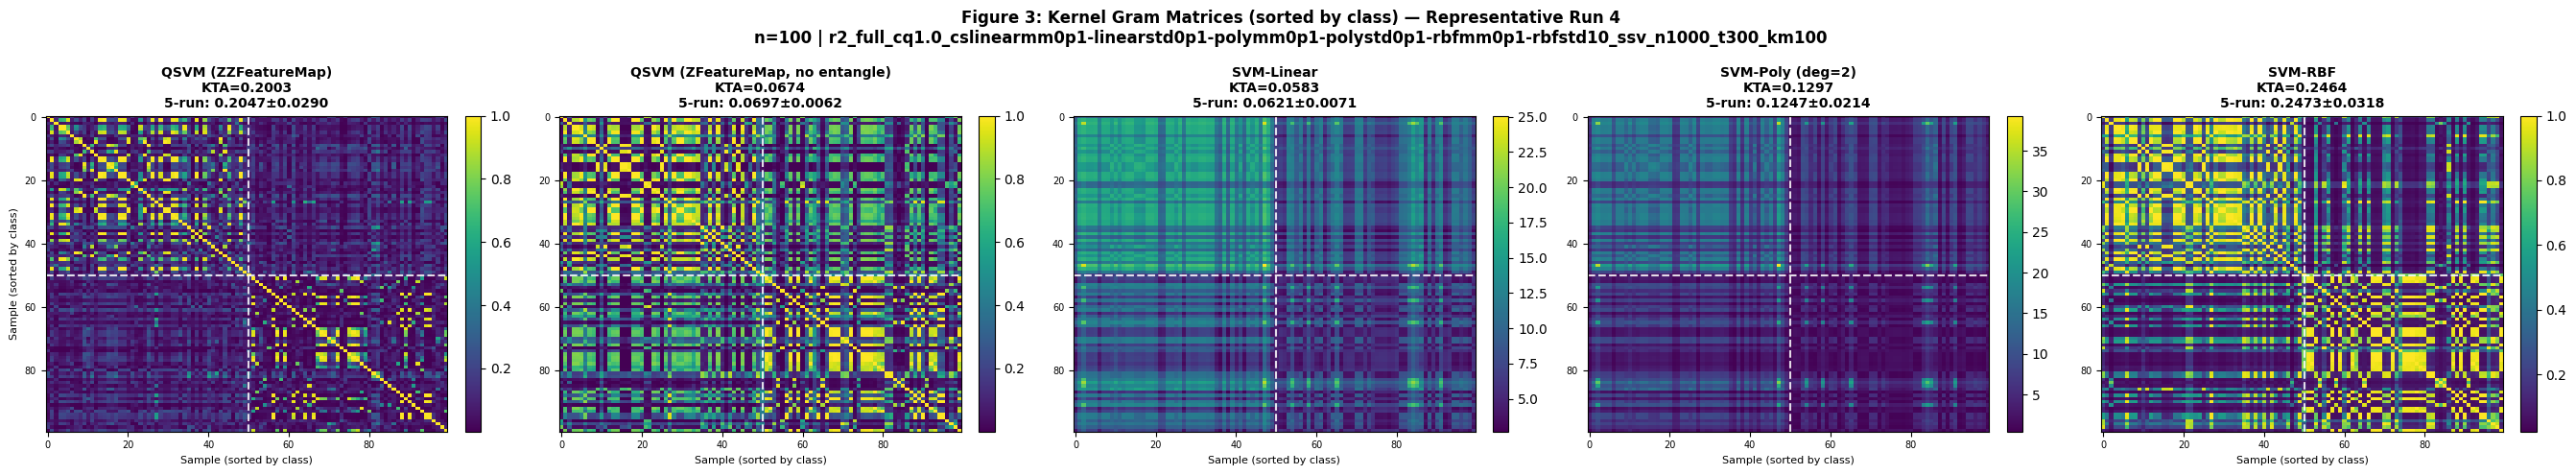

Đã lưu Figure 3: ../results/c3_multirun/c3_multirun_fig3_gram_run4_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png


In [121]:
# ════════════════════════════════════════════════════════════════════════
# FIGURE 3: Gram Matrices — 5 kernels (Representative Run)
# ════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 5, figsize=(27, 5))
fig3.suptitle(
    f'Figure 3: Kernel Gram Matrices (sorted by class) — Representative Run {REPRESENTATIVE_RUN_ID}\n'
    f'n={KM_SAMPLE_SIZE} | {CONFIG_TAG}',
    fontsize=12, fontweight='bold'
)

for col_idx, lbl in enumerate(['quantum','quantum_z','linear','poly','rbf']):
    ax  = axes3[col_idx]
    K   = km_matrices.get(lbl)
    if K is None:
        ax.text(0.5,0.5,'not available',ha='center',va='center',transform=ax.transAxes); continue
    K_s = K[sort_idx][:,sort_idx]
    im  = ax.imshow(K_s, aspect='auto', cmap='viridis', vmin=K_s.min(), vmax=K_s.max(), interpolation='nearest')
    ax.axhline(boundary, color='white', lw=1.5, ls='--', alpha=0.85)
    ax.axvline(boundary, color='white', lw=1.5, ls='--', alpha=0.85)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    kta_v    = kta_scores.get(lbl, float('nan'))
    mm_key   = lbl if lbl in ('quantum','quantum_z') else f'{lbl}_mm'
    kta_mean = agg[agg['model_key']==mm_key]['mean_kta'].values
    kta_std  = agg[agg['model_key']==mm_key]['std_kta'].values
    kta_multi = f'\n5-run: {kta_mean[0]:.4f}±{kta_std[0]:.4f}' if len(kta_mean) else ''
    ax.set_title(f'{LABEL_NAMES.get(lbl,lbl)}\nKTA={kta_v:.4f}{kta_multi}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Sample (sorted by class)', fontsize=8)
    if col_idx == 0: ax.set_ylabel('Sample (sorted by class)', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
fig3_path = f'{OUTPUT_DIR}/c3_multirun_fig3_gram_run{REPRESENTATIVE_RUN_ID}_{CONFIG_TAG}.png'
plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu Figure 3: {fig3_path}')


## 11. Delta Table & Multi-Run Summary

In [122]:
# ── Delta table: QSVM vs baselines (mean values) ──────────────────────────
q_f1_mean  = agg[agg['model_key']=='quantum']['mean_f1'].values[0]
q_acc_mean = agg[agg['model_key']=='quantum']['mean_acc'].values[0]

print(f'=== DELTA vs QSVM (mean over {len(RUN_IDS)} runs) ==='  )
print(f'  QSVM F1={q_f1_mean:.4f}  Acc={q_acc_mean:.4f}')
print(f'  {"Model":>14}  {"F1 mean":>10}  {"ΔF1":>8}  {"Acc mean":>10}  {"ΔAcc":>8}  {"QSVM wins?":>10}')
print('  ' + '-' * 72)
for key in ['quantum_z','linear_mm','poly_mm','rbf_mm','linear_std','poly_std','rbf_std']:
    row = agg[agg['model_key']==key]
    if row.empty: continue
    r = row.iloc[0]
    df1 = q_f1_mean - r.mean_f1
    da  = q_acc_mean - r.mean_acc
    wins= '✓ QSVM' if df1>0 else ('✗ SVM' if df1<0 else '=')
    print(f'  {key:>14}  {r.mean_f1:>10.4f}  {df1:>+8.4f}  {r.mean_acc:>10.4f}  {da:>+8.4f}  {wins:>10}')

# ── Spearman summary ───────────────────────────────────────────────────────
print(f'\n=== Spearman Correlation (rep run {REPRESENTATIVE_RUN_ID}) ===')
for i in range(N_QUBITS):
    for j in range(i+1, N_QUBITS):
        sp = spearman_mat[i,j]; pe = pearson_mat[i,j]
        if abs(sp) > 0.05:
            print(f'  {PC_LABELS[i]}–{PC_LABELS[j]}: Pearson={pe:+.4f}  Spearman={sp:+.4f}  nonlinear={abs(sp)-abs(pe):+.4f}')


=== DELTA vs QSVM (mean over 5 runs) ===
  QSVM F1=0.8538  Acc=0.8540
           Model     F1 mean       ΔF1    Acc mean      ΔAcc  QSVM wins?
  ------------------------------------------------------------------------
       quantum_z      0.8271   +0.0266      0.8273   +0.0267      ✓ QSVM
       linear_mm      0.8134   +0.0404      0.8140   +0.0400      ✓ QSVM
         poly_mm      0.8122   +0.0416      0.8133   +0.0407      ✓ QSVM
          rbf_mm      0.8132   +0.0406      0.8140   +0.0400      ✓ QSVM
      linear_std      0.8182   +0.0356      0.8187   +0.0353      ✓ QSVM
        poly_std      0.8293   +0.0245      0.8300   +0.0240      ✓ QSVM
         rbf_std      0.8384   +0.0154      0.8387   +0.0153      ✓ QSVM

=== Spearman Correlation (rep run 4) ===
  PC1–PC2: Pearson=-0.0219  Spearman=-0.1389  nonlinear=+0.1170
  PC1–PC3: Pearson=-0.0276  Spearman=+0.3569  nonlinear=+0.3293
  PC1–PC4: Pearson=-0.0763  Spearman=-0.0594  nonlinear=-0.0169
  PC2–PC3: Pearson=+0.0007  Spearman=

## 12. Lưu Kết Quả

In [123]:
# ── Summary JSON ──────────────────────────────────────────────────────────
def safe_val(arr, default=float('nan')):
    return float(arr[0]) if len(arr) > 0 else default

summary_mr = {
    'config_tag'             : CONFIG_TAG,
    'n_runs'                 : len(RUN_IDS),
    'representative_run_id'  : REPRESENTATIVE_RUN_ID,
    'train_size'             : TRAIN_SIZE,
    'test_size'              : TEST_SIZE,
    'km_sample_size'         : KM_SAMPLE_SIZE,
    'reps'                   : REPS,
    'entanglement'           : ENTANGLEMENT,
    'C_QSVM'                 : C_QSVM,
    'SVM_C_BY_MODEL'         : {k: float(v) for k,v in SVM_C_BY_MODEL.items()},
}
for key in KEY_ORDER:
    row = agg[agg['model_key']==key]
    if row.empty: continue
    r = row.iloc[0]
    summary_mr.update({
        f'mean_f1_{key}'  : float(r.mean_f1),
        f'std_f1_{key}'   : float(r.std_f1),
        f'mean_acc_{key}' : float(r.mean_acc),
        f'std_acc_{key}'  : float(r.std_acc),
        f'mean_kta_{key}' : float(r.mean_kta),
        f'std_kta_{key}'  : float(r.std_kta),
        f'mean_nsv_{key}' : float(r.mean_nsv),
        f'std_nsv_{key}'  : float(r.std_nsv),
    })

summary_path = f'{OUTPUT_DIR}/c3_multirun_summary_{CONFIG_TAG}.json'
with open(summary_path, 'w') as fp:
    json.dump(summary_mr, fp, indent=2)

# ── Print file list ────────────────────────────────────────────────────────
print('=== ĐÃ LƯU ===')
files_to_check = [
    (f'c3_multirun_per_run_{CONFIG_TAG}.csv',                       'Per-run metrics (all models × runs)'),
    (f'c3_multirun_summary_{CONFIG_TAG}.csv',                       'Mean ± Std aggregated summary'),
    (f'c3_multirun_summary_{CONFIG_TAG}.json',                      'Summary JSON'),
    (f'c3_multirun_f1_acc_{CONFIG_TAG}.png',                        'Figure 4: F1 & Acc mean±std bar chart'),
    (f'c3_multirun_kta_{CONFIG_TAG}.png',                           'Figure 5: KTA mean±std'),
    (f'c3_multirun_nsv_{CONFIG_TAG}.png',                           'Figure 6: n_SV mean±std'),
    (f'c3_multirun_trend_{CONFIG_TAG}.png',                         'Figure 7: Per-run trend lines'),
    (f'c3_multirun_fig1_overview_run{REPRESENTATIVE_RUN_ID}_{CONFIG_TAG}.png',  'Figure 1: Overview (8 panels)'),
    (f'c3_multirun_fig2_decision_run{REPRESENTATIVE_RUN_ID}_{CONFIG_TAG}.png',  'Figure 2: Decision boundary 5×2'),
    (f'c3_multirun_fig3_gram_run{REPRESENTATIVE_RUN_ID}_{CONFIG_TAG}.png',      'Figure 3: Gram matrices 5 kernels'),
]
for fname, info in files_to_check:
    status = '✓' if os.path.exists(f'{OUTPUT_DIR}/{fname}') else '✗'
    print(f'  {status} {fname:<70} {info}')

# ── Display styled summary table ───────────────────────────────────────────
display_rows = []
for key in KEY_ORDER:
    row = agg[agg['model_key']==key]
    if row.empty: continue
    r = row.iloc[0]
    display_rows.append({
        'Model'       : key,
        'F1 mean±std' : f'{r.mean_f1:.4f} ± {r.std_f1:.4f}',
        'Acc mean±std': f'{r.mean_acc:.4f} ± {r.std_acc:.4f}',
        'KTA mean±std': f'{r.mean_kta:.4f} ± {r.std_kta:.4f}',
        'n_SV mean±std': f'{r.mean_nsv:.1f} ± {r.std_nsv:.1f}',
        'SV ratio'    : f'{r.mean_svr:.3f}',
    })
display(pd.DataFrame(display_rows).style.hide(axis='index'))


=== ĐÃ LƯU ===
  ✓ c3_multirun_per_run_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.csv Per-run metrics (all models × runs)
  ✓ c3_multirun_summary_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.csv Mean ± Std aggregated summary
  ✓ c3_multirun_summary_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.json Summary JSON
  ✓ c3_multirun_f1_acc_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png Figure 4: F1 & Acc mean±std bar chart
  ✓ c3_multirun_kta_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png Figure 5: KTA mean±std
  ✓ c3_multirun_nsv_r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100.png Figure 6: n_SV mean±std
  ✓ c3_multirun_trend_r2_full_cq1.0_cslinearmm0p1-linea

Model,F1 mean±std,Acc mean±std,KTA mean±std,n_SV mean±std,SV ratio
quantum,0.8538 ± 0.0157,0.8540 ± 0.0157,0.2047 ± 0.0290,277.4 ± 14.7,0.277
quantum_z,0.8271 ± 0.0151,0.8273 ± 0.0150,0.0697 ± 0.0062,326.6 ± 20.8,0.327
linear_mm,0.8134 ± 0.0160,0.8140 ± 0.0155,0.0621 ± 0.0071,368.6 ± 14.7,0.369
poly_mm,0.8122 ± 0.0193,0.8133 ± 0.0187,0.1247 ± 0.0214,348.8 ± 18.6,0.349
rbf_mm,0.8132 ± 0.0167,0.8140 ± 0.0161,0.2473 ± 0.0318,406.8 ± 12.9,0.407
linear_std,0.8182 ± 0.0089,0.8187 ± 0.0087,0.0621 ± 0.0071,365.6 ± 16.4,0.366
poly_std,0.8293 ± 0.0344,0.8300 ± 0.0336,0.1247 ± 0.0214,404.0 ± 9.3,0.404
rbf_std,0.8384 ± 0.0133,0.8387 ± 0.0135,0.2473 ± 0.0318,266.8 ± 17.0,0.267


## 13. Summary — Contribution 3 Multi-Run

In [124]:
q_f1_mean  = agg[agg['model_key']=='quantum']['mean_f1'].values[0]
q_f1_std   = agg[agg['model_key']=='quantum']['std_f1'].values[0]
qz_f1_mean = agg[agg['model_key']=='quantum_z']['mean_f1'].values[0]
q_kta_mean = agg[agg['model_key']=='quantum']['mean_kta'].values[0]
qz_kta_mean= agg[agg['model_key']=='quantum_z']['mean_kta'].values[0]
q_nsv_mean = agg[agg['model_key']=='quantum']['mean_nsv'].values[0]

print('=' * 72)
print('  CONTRIBUTION 3 — KERNEL GEOMETRY (MULTI-RUN: 5 TRAIN × 1 TEST)')
print('=' * 72)
print(f'  CONFIG_TAG   : {CONFIG_TAG}')
print(f'  Runs         : {RUN_IDS}')
print(f'  Representative run: {REPRESENTATIVE_RUN_ID}')
print(f'  Circuit ZZ   : ZZFeatureMap, {N_QUBITS} qubits, reps={REPS}, entanglement={ENTANGLEMENT}')
print(f'  Circuit Z    : ZFeatureMap,  {N_QUBITS} qubits, reps={REPS_Z} (no entanglement)')
print()
print('  [1] F1-macro Mean ± Std (5 runs)')
for key in KEY_ORDER:
    row = agg[agg['model_key']==key]
    if row.empty: continue
    r = row.iloc[0]
    print(f'      {key:>14}: {r.mean_f1:.4f} ± {r.std_f1:.4f}')
print()
print('  [2] KTA Mean ± Std (5 runs)')
for key in ['quantum','quantum_z','linear_std','poly_std','rbf_std']:
    row = agg[agg['model_key']==key]
    if row.empty: continue
    r = row.iloc[0]
    print(f'      {key:>14}: {r.mean_kta:.4f} ± {r.std_kta:.4f}')
print(f'      Δ KTA (ZZ - Z): {q_kta_mean - qz_kta_mean:+.4f}')
print()
print('  [3] n_SV Mean ± Std (5 runs)')
for key in ['quantum','quantum_z','linear_std','poly_std','rbf_std']:
    row = agg[agg['model_key']==key]
    if row.empty: continue
    r = row.iloc[0]
    print(f'      {key:>14}: {r.mean_nsv:.1f} ± {r.std_nsv:.1f}  (ratio={r.mean_svr:.3f})')
print()
print('  [4] Figures generated:')
print('      Fig 1: Overview 8 panels (rep run)')
print('      Fig 2: Decision boundary 5×2 PC pairs (rep run)')
print('      Fig 3: Gram matrices 5 kernels (rep run)')
print('      Fig 4: F1 & Acc mean±std bar chart (ALL runs) ← NEW')
print('      Fig 5: KTA mean±std bar chart (ALL runs)      ← NEW')
print('      Fig 6: n_SV mean±std bar chart (ALL runs)     ← NEW')
print('      Fig 7: Per-run F1/Acc trend lines (ALL runs)  ← NEW')
print()
print('  [KEY FINDING]')
if q_kta_mean > agg[agg['model_key']=='rbf_std']['mean_kta'].values[0]:
    print(f'      QSVM KTA ({q_kta_mean:.4f}) > SVM-RBF KTA → quantum kernel geometry')
    print(f'      tương thích tốt hơn với label structure của NSL-KDD.')
print(f'      QSVM F1 = {q_f1_mean:.4f} ± {q_f1_std:.4f}  (robust over {len(RUN_IDS)} train sets)')
print('=' * 72)


  CONTRIBUTION 3 — KERNEL GEOMETRY (MULTI-RUN: 5 TRAIN × 1 TEST)
  CONFIG_TAG   : r2_full_cq1.0_cslinearmm0p1-linearstd0p1-polymm0p1-polystd0p1-rbfmm0p1-rbfstd10_ssv_n1000_t300_km100
  Runs         : [1, 2, 3, 4, 5]
  Representative run: 4
  Circuit ZZ   : ZZFeatureMap, 4 qubits, reps=2, entanglement=full
  Circuit Z    : ZFeatureMap,  4 qubits, reps=2 (no entanglement)

  [1] F1-macro Mean ± Std (5 runs)
             quantum: 0.8538 ± 0.0157
           quantum_z: 0.8271 ± 0.0151
           linear_mm: 0.8134 ± 0.0160
             poly_mm: 0.8122 ± 0.0193
              rbf_mm: 0.8132 ± 0.0167
          linear_std: 0.8182 ± 0.0089
            poly_std: 0.8293 ± 0.0344
             rbf_std: 0.8384 ± 0.0133

  [2] KTA Mean ± Std (5 runs)
             quantum: 0.2047 ± 0.0290
           quantum_z: 0.0697 ± 0.0062
          linear_std: 0.0621 ± 0.0071
            poly_std: 0.1247 ± 0.0214
             rbf_std: 0.2473 ± 0.0318
      Δ KTA (ZZ - Z): +0.1349

  [3] n_SV Mean ± Std (5 runs)
    